# Project aim and approach

Air transportation is one of the most visible and consequential examples of a real-world complex network, which emerges from thousands of independent commercial decisions made by airlines, each optimising its own route portfolio, hub strategy, and market coverage. Using a real-world dataset comprising 3,214 airports and 66,771 scheduled flight records, the study aims to explore and characterise the structure of the global air transportation network. 

The analysis adopts ***an exploratory approach***, proceeding from a broad to a progressively finer level of granularity: it begins with the global structure and connectivity of the network as a whole, then narrows to airline-specific subnetworks to relate network topology to known business models, and finally moves to node-level properties, examining individual airports through multiple centrality measures, assortativity patterns, and community membership. 

Across these levels, the analysis is guided by four general questions: 

- How connected and how hierarchically organised is the global airport network?

- Which airports occupy positions of structural importance, and whether this importance is captured consistently across different notions of centrality?

- Whether the network displays small-world properties?

- What forces (geography and national boundaries or connectivity-based preferences) appear to shape the network's large-scale organisation?  


This layered approach allows patterns that emerge at one scale to be checked against and enriched by observations at another, letting the data itself guide the interpretation of the network's underlying organisational principles.


# Data source

The dataset used in this project represents a network of regularly scheduled flights among airports worldwide. The original data were obtained from the OpenFlights dataset (openflights.org), and subsequently processed into a format suitable for network analysis. The processed dataset is available through the Netzschleuder network catalogue ([Netzschleuder: the network catalogue, repository and centrifuge](https://networks.skewed.de/net/openflights)). 

The dataset consists of two tables: 
- nodes.csv lists 3,214 airports with identifying attributes (name, city, country, IATA/FAA and ICAO codes), geographic coordinates (latitude, longitude, altitude) and time zone information (UTC offset, daylight-saving-time rule) 
- edges.csv lists 66,771 flight records, one row per regularly occurring commercial flight by a particular airline from an airport to another, with source/target airport indices, great-circle distance, operating airline (name and code), a codeshare flag, aircraft equipment, and number of stops. It was noted in the source that multiple edges can exist between the same pair of airports when several airlines operate the route or when a single airline operates multiple flights on the same route each day


# Analytical methods



The analysis was conducted using the metrics and methods outlined below:

- ***Global descriptive statistics*** (computed on both G_full and G_simplify to quantify the effect of merging parallel edges): number of nodes and edges, density, average degree, average strength, and reciprocity.

- ***Connectivity structure*** (computed on G_undirected): number of nodes and, number and size distribution of connected components, existence and share of the giant component, network diameter and average shortest-path length (both in hops and in kilometers), global and average local clustering coefficients, degree assortativity, and max coreness.
- ***Per-airline subnetworks***: for the ten airlines with the largest number of flight records, a subgraph was extracted from G_full and the same global metrics (nodes, edges, density, average degree, average strength, reciprocity) were computed and compared, to relate network topology to known differences between hub-and-spoke and point-to-point airline business models. G_full is used because it preserves information on which airline operates each flight, allowing a separate subgraph to be constructed for each airline.
- ***Node-level analysis***: 
    - In-degree, out-degree, total degree, strength, betweenness centrality, harmonic closeness centrality, PageRank, eigenvector centrality, local clustering coefficient, eccentricity, and coreness were computed for every airport, deliberately mixing unweighted (hop-based) and weighted (traffic-based) formulations to capture complementary notions of importance. Harmonic closeness is used instead of conventional closeness because the network is disconnected, and harmonic closeness handles unreachable nodes naturally (by assigning zero contribution) rather than requiring a fully connected graph.
    - The degree distribution P(k), its complementary cumulative form P(K ≥ k), and the strength CCDF were computed on G_undirected and plotted on log-log axes to examine the shape and tail behaviour of the network's connectivity. A log-log scale is used because it linearizes power-law-like behavior and compresses the wide, multi-order-of-magnitude range of values into a readable form. To assess formally whether the heavy tail is a true power law, a power-law was then fitted to the degree and strength distributions by maximum likelihood (discrete case, with x_min estimated from the data) and compared against four alternatives (lognormal, exponential, truncated power law, and stretched exponential) using likelihood-ratio tests at the 5% significance level.
    - Spearman correlations among the main centrality measures were computed to understand how these different notions of importance relate to one another, and the top 10 airports under each of 6 selected measures (strength, degree, eigenvector, harmonic closeness, betweenness and PageRank) were examined and cross-compared to identify which airports are consistently ranked as important across multiple measures, and which stand out under only one specific notion of centrality. 
    - Concentration of connectivity: the share of all network edges incident to the top 1%, 2%, 5%, and 10% of airports by degree was computed to quantify the extent of hub dominance.
- **Assortativity and mixing patterns**: besides the scalar degree assortativity coefficient, the average nearest-neighbour degree function k_nn(k) was examined to detect degree-scale-dependent mixing patterns that a single global coefficient might conceal. Because k_nn is noisy at the node level, it was averaged within logarithmic degree bins, with 95% bootstrap confidence intervals (5,000 resamples). To test whether the observed patterns are genuine rather than a by-product of the degree sequence, the binned k_nn(k) and the degree assortativity were compared with a degree-preserving null model: 200 randomly rewired versions of the network (10 × the number of edges per realisation), in which every airport keeps its exact degree, summarised by the null mean, 95% range, and z-score per bin. Rewiring is used instead of a configuration model because it keeps the graph simple without altering degrees and shifting nodes across bins. Finally, k_nn was contrasted between the endpoints of each regime suggested by the curve (low-degree dip, mid-degree rise, high-degree decline), with each difference given a bootstrap confidence interval and compared with the 95% range of the same difference across the rewired networks. Moreover, nominal assortativity with respect to country and scalar assortativity with respect to time zone were computed to assess the network's geographic and national organisation.
- **Small-world null-model comparison**: The empirical clustering coefficient and average path length of the giant component of G_undirected were compared with those of two types of random networks. For each type, 20 random network realizations were generated: (1) an Erdős–Rényi/Gilbert model with the same number of nodes and edge density as the empirical network, and (2) a configuration model with the same degree sequence as the empirical network. The small-world coefficient (σ) was then calculated for both baselines by comparing the relative change in clustering with the relative change in average path length.
- **Community detection**: four community detection algorithms (Louvain, Walktrap, Infomap, and Label Propagation) were each run 50 times on the giant component of G_undirected. Their performance was evaluated based on modularity (Q) and the number of communities detected, while their stability across runs was assessed using pairwise Normalized Mutual Information (NMI) and Adjusted Rand Index (ARI). The best-performing algorithm was then used to obtain a final community partition, which was profiled by size, dominant countries, and the strongest hub airport per community, and visualised against real-world geographic coordinates.
A random seed (42) was set once at the start of each analysis step (algorithm screening, final Louvain run, bootstrap resampling and degree-preserving rewiring, and random-graph null-model generation) to ensure that the overall sequence of results is fully reproducible across repeated executions of the notebook, while still allowing successive draws within each step (repeated algorithm runs, repeated random-graph samples) to differ from one another. This preserves the variability needed for meaningful stability and null-model comparisons.

Note: For concept references, please find in the Appendix at the end of the report


# Main findings


**Network structure & connectivity**
- The global flight network is highly connected: 99.19% of airports belong to a single giant component, with a short average path length (~3.96 hops) despite covering 3,214 airports worldwide.


- Very high reciprocity (>0.97) across the network shows flight routes are almost always bidirectional.
- Both the degree and strength distributions exhibit heavy-tailed behavior, indicating substantial heterogeneity in the network: most airports have relatively few connections and low traffic volume, while a small number of major hubs have exceptionally high values. Maximum-likelihood analysis supports this heavy-tailed structure, although likelihood-ratio tests show that the power law is significantly outperformed by the lognormal, truncated power-law, and stretched-exponential alternatives. Thus, the network is heavy-tailed, but is not best characterized as a pure power-law network.

**Hub dominance & airport importance**
- Connectivity is heavily concentrated: the top 1% of airports account for 28.5% of all edges, rising to 84.5% for the top 10%, showing a clear quantitative evidence of hub-and-spoke organization.


- Hub importance is multi-dimensional, not a single ranking. In more detail, different centrality measures identify different types of hubs: Atlanta and Amsterdam lead in strength and degree, respectively; Atlanta and Heathrow top the eigenvector centrality ranking; Frankfurt, Paris, and Amsterdam dominate harmonic closeness; while Paris and Los Angeles emerge as key strategic bridges under betweenness centrality. 
- Being important under one metric does not guarantee similar importance under another. Anchorage illustrates this clearly: despite its modest traffic volume, it plays a disproportionately important bridging role, as reflected by its high betweenness centrality. Atlanta shows the opposite pattern: despite ranking first in both strength and eigenvector centrality, it does not appear among the top ten airports by betweenness centrality.

**Airline business models**
- U.S. major carriers (AA, UA, DL, US) show hub-and-spoke signatures: large networks with low density, though part of this low density is a mechanical size effect rather than purely structural


- Ryanair, easyJet, and Southwest show point-to-point signatures: smaller networks with both high density and high average degree (Ryanair operates the most routes of any carrier despite serving relatively fewer airports), so the point-to-point reading holds even after accounting for network size.

**Small-world properties**
- The network is a genuine small-world network: Its empirical clustering coefficient is roughly 67 times higher than that of an Erdős–Rényi random graph and about 3.2 times higher than that of a degree-matched configuration model, while the average path length increases only modestly by comparison. Even after controlling for the network's heterogeneous degree distribution, the small-world coefficient sigma remains well above 1 (σ ≈ 2.67), confirming that small-world structure is an intrinsic property of the network rather than merely an artifact of its skewed degree sequence.

**Assortativity / geographic mixing**: 
- Although the overall degree assortativity coefficient is close to zero, a deeper examination of the average-nearest-neighbour-degree function k_nn(k) reveals that this near-zero does not reflect an absence of degree-based mixing but instead conceals opposing tendencies at different degree scales: a dip at low degrees and a rise at mid degrees, which largely cancel out in the global average. 


- Airports connect much more within the same country (assortativity 0.445) and same time zone (0.906) than random chance would predict.
- Therefore, geography and national boundaries emerge as the clearer, more straightforward organising factors of the network, while degree-based connectivity still plays a real but scale-dependent role.

**Community structure**
- Louvain is selected over Infomap, Walktrap and Label Propagation to detect communities for this network because it provides the highe modularity while maintaining good stability and a relatively compact and interpretable community structure.

- It detected 17 communities (Q ≈ 0.65). With no geographic data given to the algorithm. it still maps well real-world continents/regions (North America, Europe, Asia-Pacific, South Asia/Middle East, East Asia, South America), strongly validating that geography drives the network's mesoscale organization.


- Each community's top hub matches a real-world major airport (Atlanta, Paris CDG, Singapore, Dubai, Beijing, São Paulo), reinforcing external validity of the result, though it should be noted that this specific profile reflects a single run.  

# 1. Imports and plotting style

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import igraph as ig
import networkx as nx
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import adjusted_rand_score as ARI
import powerlaw

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# set a random seed for reproducibility for community detection and random-graph null models
import random
RANDOM_SEED = 42 
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 2. Data loading and graph building

According to the data source:
- Nodes represent airports, and direction of edge (i,j) indicates a regularly occurring commercial flight by a particular airline from airport i to airport j.
- Multiple edges may exist between a pair of airports if multiple airlines offer that flight, or if one airline offers multiple such flights each day.

For the objectives of the analysis, three graph representations were built from the same data, each suited to a different type of analysis:
- **`G_full`**: a directed multigraph containing one edge per original flight record. This representation preserves both the direction of flights and multiple edges between the same pair of airports, allowing the network to capture airline-specific and flight-level information. Therefore, it is used whenever airline-specific information is required, such as when constructing per-airline subnetworks. 

- **`G_simplify`**: a simplified directed graph with a single edge per unique ordered airport pair, obtained by merging parallel edges in `G_full`. This representation is used for degree and strength-based, and directed centrality analyses.
  - Edge weight equals the number of original flight records merged into that edge;
  - Route distance is averaged; 
  - The number of stops is taken as the minimum observed; 
  - The number of distinct airlines serving the route is recorded. 


- **`G_undirected`**: An undirected weighted graph derived from `G_simplify` by collapsing opposite directed edges *(i → j)* and *(j → i)* into a single undirected edge *(i, j)*. Edge weights are summed across both directions, while other edge attributes are combined appropriately. This representation is used for analyses that are conventionally defined on undirected networks, including connected components, clustering coefficients, coreness, average shortest path length, diameter, and community detection.


In [2]:
DATA_DIR = Path("flights_network_dataset")

def load_nodes(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    df = pd.read_csv(data_dir / "nodes.csv")
    return df.sort_values("index").reset_index(drop=True)

def load_edges(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    return pd.read_csv(data_dir / "edges.csv")

# Build G_full graph with all edges
def build_full_graph(nodes_df: pd.DataFrame, edges_df: pd.DataFrame, directed: bool = True) -> ig.Graph:
    n = len(nodes_df)
    g = ig.Graph(n=n, directed=directed)

    vertex_cols = ["id", "name", "city", "country", "IATA/FAA", "ICAO",
                   "latitude", "longitude", "altitude", "timezone", "DST"]
    for col in vertex_cols:
        if col in nodes_df.columns:
            g.vs[col] = nodes_df[col].tolist()
    g.vs["label"] = nodes_df["IATA/FAA"].fillna(nodes_df["name"]).tolist()

    valid = edges_df[edges_df["source"].between(0, n - 1) & edges_df["target"].between(0, n - 1)]
    g.add_edges(list(zip(valid["source"], valid["target"])))
    g.es["weight"] = 1

    edge_cols = ["distance", "airline", "airline_code", "codeshare", "equipment", "stops"]
    for col in edge_cols:
        if col in valid.columns:
            g.es[col] = valid[col].tolist()
    return g

# Build G_simplify graph by merging parallel edges with the same direction into a single directed edge.
def build_simplify_graph(g_full: ig.Graph) -> ig.Graph:
    g = g_full.copy()
    g.es["airline_list"] = [[a] for a in g.es["airline_code"]]
    g.simplify(multiple=True, loops=True, combine_edges={
        "weight": "sum",                                        # Sum the weights of parallel edges
        "distance": "mean",                                     # Average the distances of parallel edges
        "stops": "min",                                         # Keep the minimum number of stops of parallel edges
        "airline_list": lambda lists: sorted(set(a for sub in lists for a in sub)), # List of distinct airlines on the route
    })
    g.es["n_airlines"] = [len(x) for x in g.es["airline_list"]]
    return g

# Build G_undirected graph by collapsing opposite directed edges (A→B and B→A) into a single undirected edge.
def as_undirected_weighted(g: ig.Graph) -> ig.Graph:
    if not g.is_directed():
        return g
    combine = {a: "sum" for a in ["weight", "n_airlines"] if a in g.es.attributes()}            # Sum the weights of opposite directed edges.
    if "distance" in g.es.attributes():
        combine["distance"] = "mean"                                                            # Average the distances of opposite directed edges.
    if "stops" in g.es.attributes():                                                            # Keep the minimum number of stops across opposite directed edges.
        combine["stops"] = "min"
    return g.as_undirected(mode="collapse", combine_edges=combine)


nodes_df = load_nodes()
edges_df = load_edges()

G_full = build_full_graph(nodes_df, edges_df, directed=True)
G_simplify = build_simplify_graph(G_full)
G_undirected = as_undirected_weighted(G_simplify)

print(G_full.summary())
print(G_simplify.summary())
print(G_undirected.summary())

IGRAPH DNW- 3214 66771 -- 
+ attr: DST (v), IATA/FAA (v), ICAO (v), altitude (v), city (v), country (v), id (v), label (v), latitude (v), longitude (v), name (v), timezone (v), airline (e), airline_code (e), codeshare (e), distance (e), equipment (e), stops (e), weight (e)
IGRAPH DNW- 3214 36906 -- 
+ attr: DST (v), IATA/FAA (v), ICAO (v), altitude (v), city (v), country (v), id (v), label (v), latitude (v), longitude (v), name (v), timezone (v), airline_list (e), distance (e), n_airlines (e), stops (e), weight (e)
IGRAPH UNW- 3214 18858 -- 
+ attr: DST (v), IATA/FAA (v), ICAO (v), altitude (v), city (v), country (v), id (v), label (v), latitude (v), longitude (v), name (v), timezone (v), distance (e), n_airlines (e), stops (e), weight (e)


# 3. Network Overview and Descriptive Analysis

## 3.1. G_full vs G_simplify

This section compares `G_full` and `G_simplify` in terms of the number of nodes and edges, density, average degree, average strength and reciprocity. Looking at both representations helps illustrate how merging parallel edges changes the network structure, before G_simplify is used as the default representation for the rest of the notebook.

In [3]:
def compute_global_metrics(g: ig.Graph, label: str = "network") -> dict:
    n = g.vcount()
    m = g.ecount()

    return {
        "network": label,
        "nodes": n,
        "edges": m,
        "density": g.density(),
        "avg_degree": np.mean(g.degree()),
        "avg_strength": np.mean(g.strength(weights="weight")) if "weight" in g.es.attributes() else np.nan,
        "reciprocity": g.reciprocity()

    }


global_stats = pd.DataFrame([
    compute_global_metrics(G_full, "G_full (multigraph)"),
    compute_global_metrics(G_simplify, "G_simplify (directed)")
])
global_stats

,network,nodes,edges,density,avg_degree,avg_strength,reciprocity
0,G_full (multigraph),3214,66771,0.006466,41.550093,41.550093,0.972592
1,G_simplify (directed),3214,36906,0.003574,22.965775,41.549471,0.978052


- After combining the parallel edges, the network becomes substantially sparser, with the number of edges decreasing from 66,771 in `G_full` to 36,906 in `G_simplify` (approximately 45%). This indicates that a substantial number of routes are operated by multiple airlines.


- On average, each airport is connected to approximately 42 individual flight records, which are consolidated into about 23 unique outgoing and incoming routes after simplification.
- The average strength remains almost unchanged, demonstrating that `G_simplify` successfully preserves the multiplicity of the original flight records.
- The reciprocity remains very high in both networks, meaning that most flight routes operate in both directions. There is a small increase in reciprocity from 0.973 in `G_full` to 0.978 in `G_simplify` because in `G_full`, parallel edges represent individual flight records, while in `G_simplify`, they are consolidated into unique routes.

## 3.2. G_undirected

For `G_undirected`, additional structural measures that are conventionally defined for undirected networks, including connected components, clustering coefficients, coreness, and path-based metrics, are computed to provide further insights into the network structure. 
Since the network has a very high reciprocity as shown above, converting the directed network into an undirected one removes relatively little information about the overall connectivity structure.

In [4]:
def compute_metrics(g: ig.Graph, label: str = "G_undirected") -> dict:

    giant = g.components().giant()

    return {
        "network": label,
        "nodes": g.vcount(),
        "edges": g.ecount(),
        "n_components": len(g.components()),
        "giant_component_share": giant.vcount() / g.vcount(),
        "diameter_hops": giant.diameter(),
        "avg_path_length_hops": giant.average_path_length(),
        "global_clustering": g.transitivity_undirected(),
        "avg_local_clustering": g.transitivity_avglocal_undirected(mode="zero"),
        "assortativity_degree": g.assortativity_degree(directed=False),
        "max_core": max(g.coreness()),
    }

global_stats_undirected = pd.DataFrame([
    compute_metrics(G_undirected, "G_undirected"),
])
global_stats_undirected

,network,nodes,edges,n_components,giant_component_share,diameter_hops,avg_path_length_hops,global_clustering,avg_local_clustering,assortativity_degree,max_core
0,G_undirected,3214,18858,7,0.99191,12,3.95853,0.249717,0.491773,-0.016673,31


- After collapsing opposite directed edges into single undirected edges, the edge count nearly halves from 36,906 in G_simplify to 18,858 in G_undirected. In more details, 18,048 unique undirected connections are bidirectional routes, while 810 are one-way connections.


- The network consists of 7 connected components, with 99.19% of airports belonging to the giant component. The remaining 6 components are relatively small and disconnected from the main airport network, comprising around 26 airports in total.
- The giant component has a diameter of 12 hops, while the average shortest path is only 3.96 hops. This indicates that airports within the giant component are relatively well connected in terms of the number of flight connections required to reach one another.
- With the `global_clustering` of around 0.25 and `avg_local_clustering` of around 0.49, the network exhibits substantial clustering. Combined with the relatively short average shortest path, this suggests potential small-world characteristics. This hypothesis is tested formally against random-graph null models in Section 7.
- The `degree assortativity` is close to zero (-0.017), indicating little correlation between the degrees of connected airports.
- The `maximum core number` is 31, indicating the presence of a dense core in which each airport maintains at least 31 connections within the core. This suggests a strongly interconnected group of airports at the center of the network.

## 3.3. Per-airline subnetworks

For this section, the sub-network characteristics of the top 10 airlines by number of flights are examined. For each airline, a subgraph is extracted from `G_full`, as it is the only representation that preserves information about which airline operates each flight. Global network metrics are then computed to identify differences in network size, connectivity, and organizational structure, particularly between hub-and-spoke and point-to-point operations. 

The global network metrics are:

- **Number of nodes**: The number of airports served by the airline, indicating network size.
- **Number of edges**: The number of direct routes operated by the airline after merging duplicate routes.
- **Network density**: Higher density generally indicates a more point-to-point structure, while lower density is more characteristic of hub-and-spoke operations.
- **Average degree**: The average number of direct route connections per airport, indicating overall network connectivity.
- **Average strength**: The average weighted degree of airports, where edge weights represent the number of parallel flights between airport pairs.
- **Reciprocity**: The proportion of routes that are bidirectional.

In [5]:
top_10_airlines = edges_df["airline_code"].value_counts().head(10).index.tolist()

def airline_subgraph(g_full: ig.Graph, airline_code) -> ig.Graph:
    eids = [e.index for e in g_full.es if e["airline_code"] == airline_code]
    sub = g_full.subgraph_edges(eids, delete_vertices=True)
    sub.es["weight"] = 1
    sub.simplify(multiple=True, loops=True, combine_edges={
        "weight": "sum", "distance": "mean", "stops": "min",
    })
    return sub

airline_graphs = {}
for code_ in top_10_airlines:
    airline_graphs[code_] = airline_subgraph(G_full, code_)

airline_code_map = (edges_df[["airline_code", "airline"]].drop_duplicates(subset="airline_code").set_index("airline_code")["airline"])

airline_stats = pd.DataFrame([
    compute_global_metrics(g, label=str(code_)) for code_, g in airline_graphs.items()
]).sort_values("nodes", ascending=False).reset_index(drop=True)

airline_stats["airline"] = airline_stats["network"].map(airline_code_map)

airline_stats

,network,nodes,edges,density,avg_degree,avg_strength,reciprocity,airline
0,24,433,2352,0.012574,10.863741,10.863741,0.988095,AA
1,5209,431,2178,0.011752,10.106729,10.106729,0.977961,UA
2,2009,354,1981,0.015853,11.192090,11.192090,0.987380,DL
3,5265,352,1960,0.015864,11.136364,11.136364,0.974490,US
4,1758,218,1251,0.026445,11.477064,11.477064,0.999201,MU
5,1767,189,1446,0.040696,15.301587,15.301587,0.998617,CZ
6,751,186,1244,0.036152,13.376344,13.376344,0.998392,CA
7,4296,176,2484,0.080649,28.227273,28.227273,1.000000,FR
8,2297,128,1130,0.069513,17.656250,17.656250,1.000000,U2
9,4547,95,1146,0.128331,24.126316,24.126316,0.996510,WN


Note: It can be observed that `avg_degree` equals to `avg_strength`. This is because all edges in the individual airline subgraphs have a weight of 1. Therefore, average strength is identical to average degree and provides no additional information.

In [6]:
airline_info = {
    "AA": {"name": "American Airlines", "country": "United States"},
    "UA": {"name": "United Airlines", "country": "United States"},
    "DL": {"name": "Delta Air Lines", "country": "United States"},
    "US": {"name": "US Airways", "country": "United States"},
    "MU": {"name": "China Eastern Airlines", "country": "China"},
    "CZ": {"name": "China Southern Airlines", "country": "China"},
    "CA": {"name": "Air China", "country": "China"},
    "FR": {"name": "Ryanair", "country": "Ireland"},
    "U2": {"name": "easyJet", "country": "United Kingdom"},
    "WN": {"name": "Southwest Airlines", "country": "United States"}
}
airline_info_df = pd.DataFrame.from_dict(airline_info, orient="index")
airline_info_df

,name,country
AA,American Airlines,United States
UA,United Airlines,United States
DL,Delta Air Lines,United States
US,US Airways,United States
MU,China Eastern Airlines,China
CZ,China Southern Airlines,China
CA,Air China,China
FR,Ryanair,Ireland
U2,easyJet,United Kingdom
WN,Southwest Airlines,United States


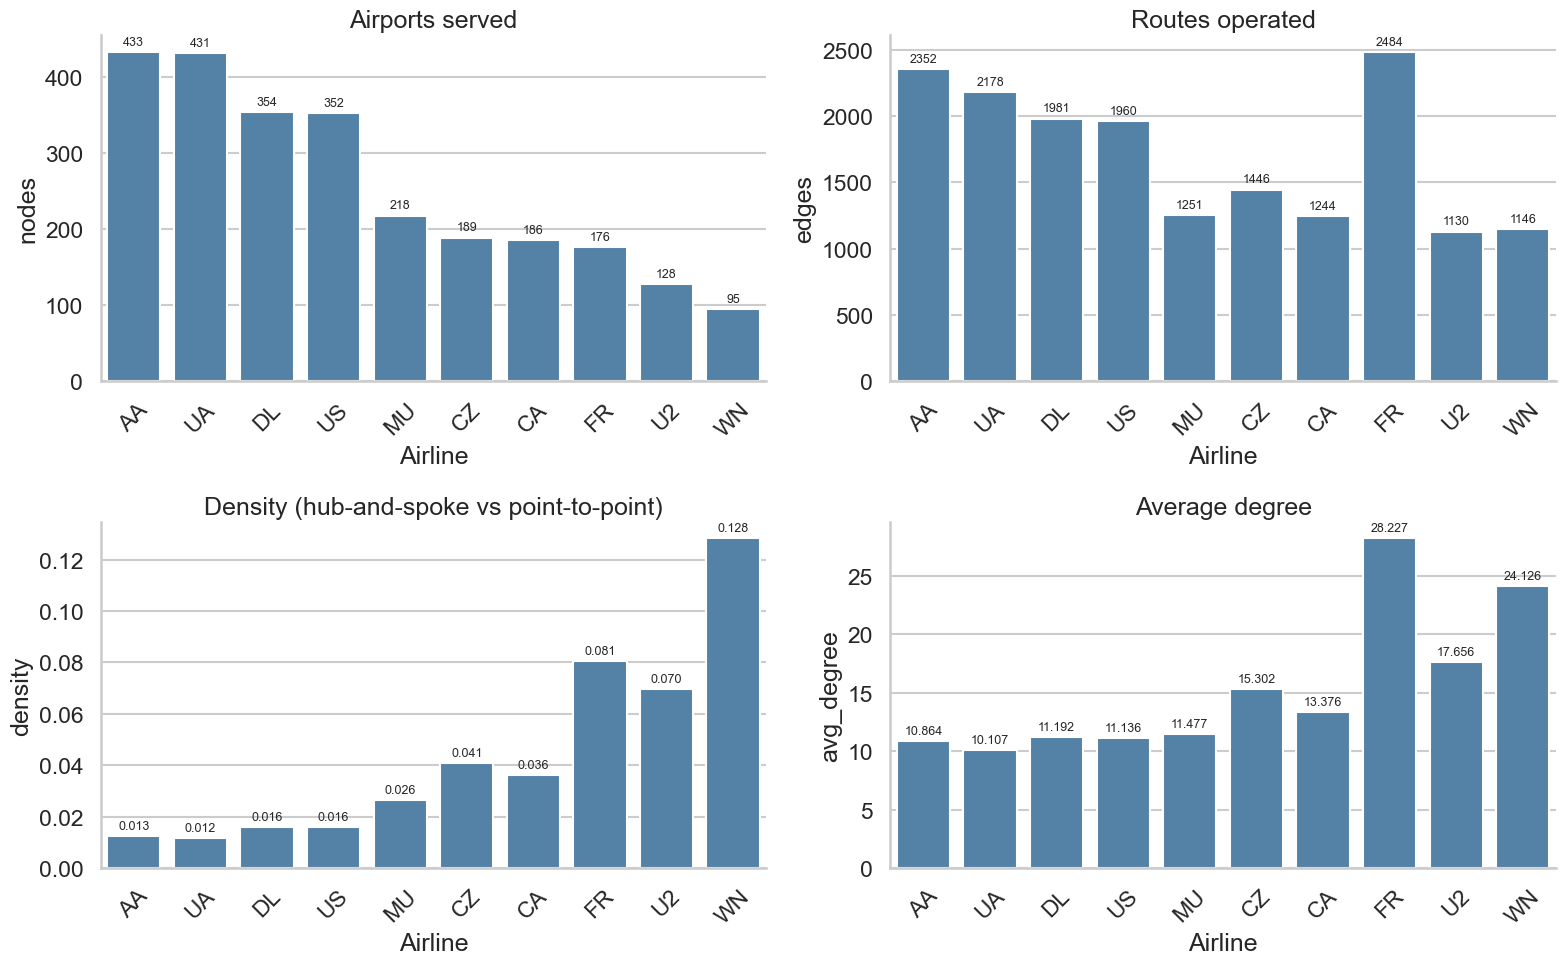

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plots = [
    ("nodes", "Airports served"),
    ("edges", "Routes operated"),
    ("density", "Density (hub-and-spoke vs point-to-point)"),
    ("avg_degree", "Average degree"),
]

for ax, (col, title) in zip(axes.flat, plots):
    sns.barplot(
        data=airline_stats,
        x="airline",
        y=col,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(title)
    ax.set_xlabel("Airline")
    ax.tick_params(axis="x", rotation=45)

    # Add value labels on top of bars
    for container in ax.containers:
        if col in ["density", "avg_degree"]:
            labels = [f"{v:.3f}" for v in airline_stats[col]]
        else:
            labels = [f"{int(v)}" for v in airline_stats[col]]

        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

- The four major U.S. carriers, namely American Airlines (AA), United Airlines (UA), Delta Air Lines (DL), and US Airways (US), operate large networks, each serving over 350 airports and around 2,000 routes. Meanwhile, their densities are among the lowest of the 10 carriers, ranging from 0.013 to 0.016. However, it should be noted that on the airline subnetworks, density falls mechanically with network size: the U.S. carriers' low density is partly an artefact of them serving 350+ airports compared with smaller networks. 

- Ryanair (FR), easyJet (U2), and Southwest Airlines (WN) operate smaller networks, serving 176, 128, and 95 airports respectively. Notably, FR serves only 176 airports yet has 2,484 routes, the highest of all 10 carriers. Combined with its high density (0.081) and, more tellingly given the smaller network size, a high average degree (28.22), this points to a highly connected point-to-point network, consistent with the airline's low-cost operating model. WN, meanwhile, exhibits the highest network density among all 10 carriers (0.128). Though part of this again reflects its small size (95 airports), its average degree (24.13) is also the second-highest overall, supporting a genuinely point-to-point rather than purely small-network effect.

- China Eastern (MU), China Southern (CZ), and Air China (CA) form a middle group between the U.S. majors and the low-cost carriers. Their networks are smaller than the U.S. majors, covering 186–218 airports, yet their density (0.026–0.041) and avg_degree (11.5–15.3) are higher, although part of this again reflects their smaller network size rather than a clearly distinct structure. 

- Reciprocity is uniformly high across all 10 carriers (0.97–1.0). This shows that nearly all routes are bidirectional regardless of network structure. 

# 4. Graphical representation of the network

## 4.1. Connected component size distribution

   component_rank  size  percentage
0               1  3188       99.19
1               2    10        0.31
2               3     4        0.12
3               4     4        0.12
4               5     4        0.12
5               6     2        0.06
6               7     2        0.06


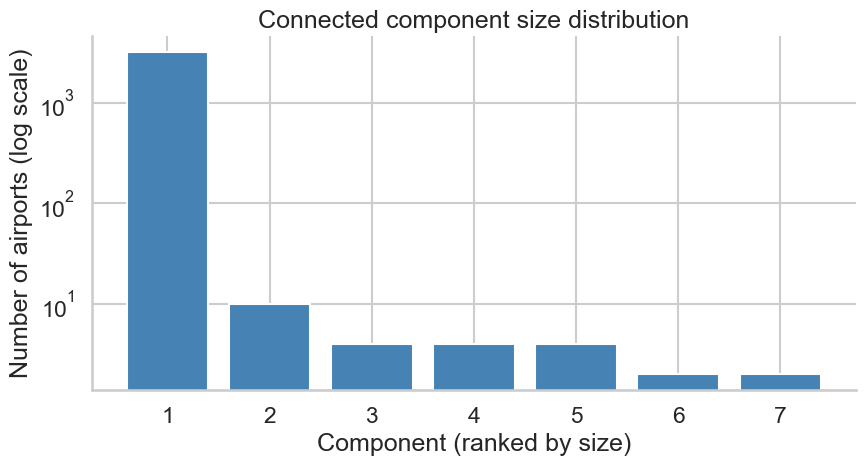

In [8]:

components = G_undirected.components()
comp_sizes = sorted((len(c) for c in components), reverse=True)
total_nodes = G_undirected.vcount()

comp_sizes_df = pd.DataFrame({
    "component_rank": range(1, len(comp_sizes) + 1),
    "size": comp_sizes,
})
comp_sizes_df["percentage"] = (comp_sizes_df["size"] / total_nodes * 100).round(2)

print(comp_sizes_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(comp_sizes_df["component_rank"].astype(str), comp_sizes_df["size"], color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("Component (ranked by size)")
ax.set_ylabel("Number of airports (log scale)")
ax.set_title("Connected component size distribution")
plt.tight_layout()
plt.show()

The network consists of 7 connected components. The largest component contains 3,188 airports, accounting for 99.19% of all airports, while the remaining six components are much smaller, ranging from 2 to 10 airports each.

## 4.2. Plotting the network with its true geographic coordinates

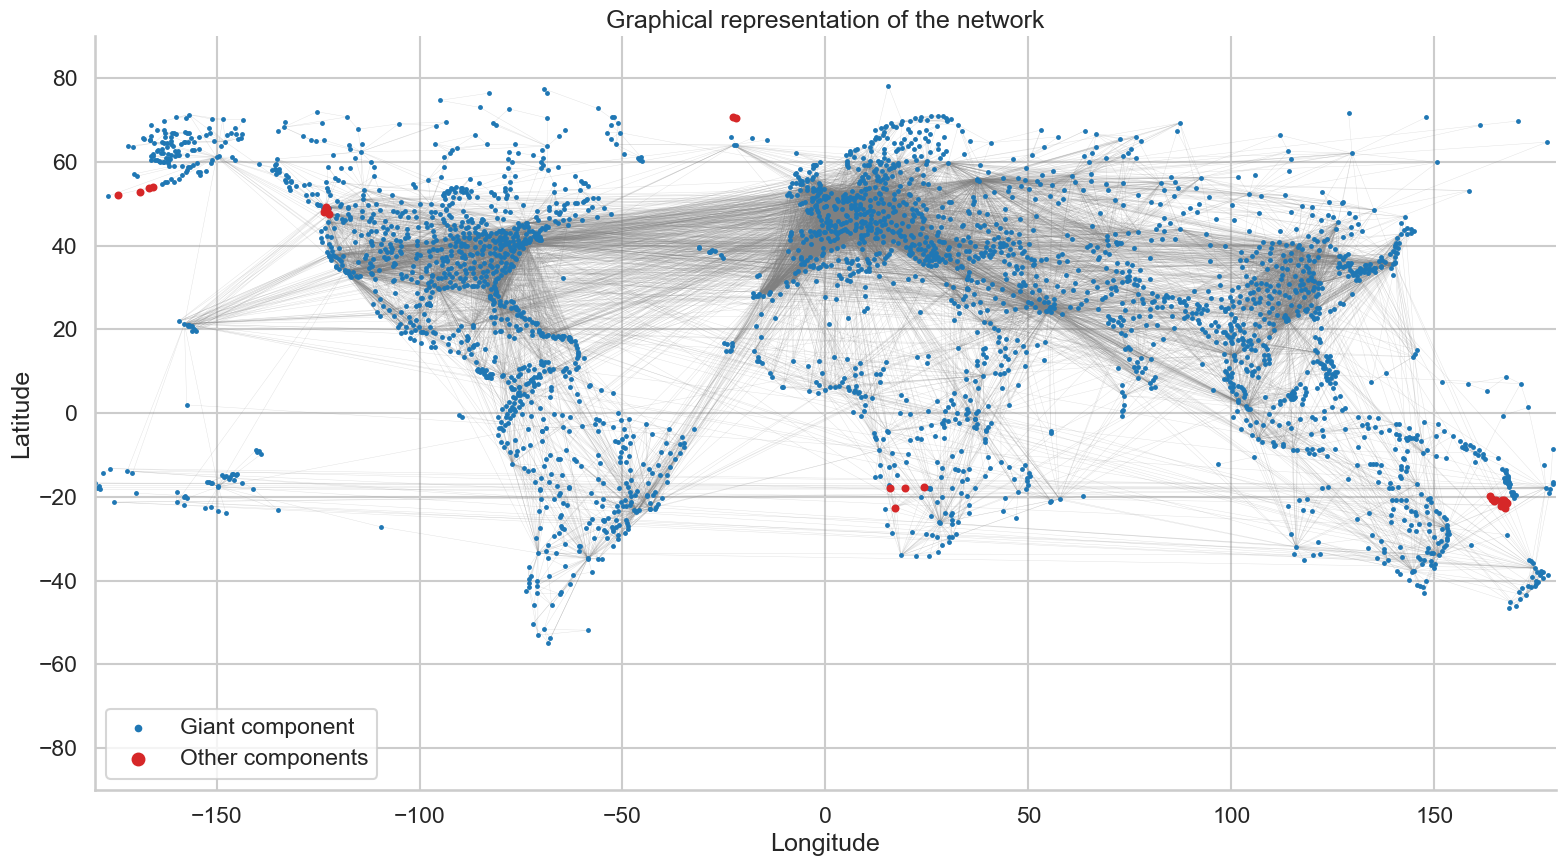

In [9]:
lon = np.array(G_undirected.vs["longitude"])
lat = np.array(G_undirected.vs["latitude"])
membership = np.array(components.membership)
giant_id = pd.Series(membership).value_counts().idxmax()
is_giant = membership == giant_id

fig, ax = plt.subplots(figsize=(16, 9))

segments = [
    ((lon[e.source], lat[e.source]), (lon[e.target], lat[e.target]))
    for e in G_undirected.es
]
ax.add_collection(LineCollection(segments, colors="gray", linewidths=0.3, alpha=0.25, zorder=1))

ax.scatter(lon[is_giant], lat[is_giant], s=4, color="#1f77b4", label="Giant component", zorder=2)
ax.scatter(lon[~is_giant], lat[~is_giant], s=18, color="#d62728", label="Other components", zorder=3)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Graphical representation of the network")
ax.legend(loc="lower left", markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

- The geographic visualization shows that the vast majority of airports belong to the giant component, represented by blue nodes, while only a small number of airports belong to the other connected components, shown in red. 


- The network has a strong global structure, with dense concentrations of airports in Europe, North America, and Asia. Numerous edges connect airports across regions and continents, highlighting the highly interconnected nature of the global air transportation network. 
- The isolated red nodes are mainly located at the network's periphery, indicating small disconnected components.

# 5. Node-level analysis

For each airport, centrality is measured on `G_simplify`, where each unique route is represented by a single edge, preventing duplicate records from inflating connectivity. Direction-sensitive measures, such as in/out-degree and PageRank, are computed on the directed graph, while closeness, betweenness, eigenvector centrality, and clustering are computed on its undirected version. Removing direction makes these measures easier to interpret consistently, as they focus on the connectivity and structural position of airports rather than the direction of individual routes.

- **in_degree / out_degree**: number of distinct arrival / departure routes.
- **degree**: total number of distinct connections (undirected).
- **strength**: the total number of airline-route entries (each airline's route counted separately) connecting to and from the airport. It reflects traffic volume, unlike degree which counts each distinct destination only once.
- **betweenness**: how often the airport lies on the shortest path between two other airports, a measure of its role as a connecting/transit hub.
- **harmonic closeness**: harmonic closeness captures a similar notion of proximity-based centrality as conventional closeness, but uses a different formulation that is better suited to disconnected networks. A higher harmonic closeness score indicates that an airport is, on average, more closely positioned to other reachable airports, making it more central within the network.
- **pagerank**: how important an airport is based on connections from other important airports, accounting for route direction.
- **eigenvector**: how important an airport is based on connections to other important airports, regardless of route direction.
- **coreness**: how deep the airport sits inside the most densely connected "core" of the network.
- **eccentricity**: maximum shortest-path distance from an airport to any other reachable airport.
- **betweenness_per_tie**: betweenness normalised by strength to flag airports that act as important connecting points despite having lower route volume.


Note: 
- ***Harmonic closeness centrality is used instead of conventional closeness centrality*** because the airport network is not fully connected. Harmonic closeness handles unreachable nodes naturally by assigning them a contribution of zero, allowing centrality to be calculated across the entire network without restricting the analysis to individual connected components.
- Centrality measures in this section deliberately mix weighted and unweighted formulations to capture two complementary perspectives. 
    - **betweenness**, **harmonic closeness**, and **eccentricity** are computed unweighted (hop-based), capturing an airport's topological reachability 
    - **eigenvector centrality**, **PageRank**, and **strength** are computed weighted, capturing an airport's traffic-based influence 

In [10]:
def harmonic_closeness_nx(g: ig.Graph, normalize: bool = True) -> np.ndarray:
    n = g.vcount()

    G_nx = nx.Graph()
    G_nx.add_nodes_from(range(n))
    G_nx.add_edges_from(g.get_edgelist())

    hc = nx.harmonic_centrality(G_nx)

    harmonic = np.array([hc[i] for i in range(n)])

    if normalize and n > 1:
        harmonic = harmonic / (n - 1)

    return harmonic


def compute_node_metrics(g: ig.Graph) -> pd.DataFrame:
    g_und = as_undirected_weighted(g)

    out_degree = np.array(g.degree(mode="out")) if g.is_directed() else np.array(g.degree())
    in_degree = np.array(g.degree(mode="in")) if g.is_directed() else out_degree
    degree = np.array(g_und.degree())
    strength = np.array(g_und.strength(weights="weight"))
    betweenness = np.array(g_und.betweenness(weights=None))
    harmonic_closeness = harmonic_closeness_nx(g_und, normalize=True)
    pagerank = np.array(g.pagerank(weights="weight"))
    eigenvector = np.array(g_und.eigenvector_centrality(weights="weight"))
    local_clustering = np.array(g_und.transitivity_local_undirected(mode="zero"))
    eccentricity = np.array(g_und.eccentricity())
    coreness = np.array(g_und.coreness())

    metrics = pd.DataFrame({
        "airport": g.vs["label"],
        "name": g.vs["name"],
        "city": g.vs["city"],
        "country": g.vs["country"],
        "in_degree": in_degree,
        "out_degree": out_degree,
        "degree": degree,
        "strength": strength,
        "betweenness": betweenness,
        "harmonic_closeness": harmonic_closeness, 
        "pagerank": pagerank,
        "eigenvector": eigenvector,
        "local_clustering": local_clustering,
        "eccentricity": eccentricity,
        "coreness": coreness,
    })
    metrics["betweenness_per_tie"] = (metrics["betweenness"] / metrics["strength"].replace(0, np.nan))
    return metrics

node_metrics = compute_node_metrics(G_simplify)

## 5.1. Summary statistics for all node metrics

In [11]:
node_metrics.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
in_degree,3214.0,11.48,24.70,0.0,1.00,3.00,8.00,238.00
out_degree,3214.0,11.48,24.77,0.0,1.00,3.00,8.00,239.00
degree,3214.0,11.73,25.03,1.0,2.00,3.00,9.00,248.00
strength,3214.0,41.55,109.44,1.0,4.00,8.00,26.00,1826.00
betweenness,3214.0,4676.29,22016.00,0.0,0.00,0.37,264.25,327988.11
harmonic_closeness,3214.0,0.27,0.05,0.0,0.24,0.27,0.30,0.46
pagerank,3214.0,0.00,0.00,0.0,0.00,0.00,0.00,0.01
eigenvector,3214.0,0.02,0.06,0.0,0.00,0.00,0.01,1.00
local_clustering,3214.0,0.49,0.39,0.0,0.00,0.50,0.93,1.00
eccentricity,3214.0,8.49,0.99,1.0,8.00,8.00,9.00,12.00


- The ***in-degree*** and ***out-degree*** distributions are nearly identical. This pattern is in line with the aforementioned finding that the network is highly reciprocal, with most routes operating in both directions.


- The ***degree*** distribution is highly right-skewed. While the average airport is connected to only 11.73 other airports, the median degree is 3. This indicates that at least half of the airports have three or fewer connections, whereas a small number of major hubs have exceptionally high connectivity, reaching up to 248.
- ***Strength*** exhibits even greater variation than degree. The median strength is only 8, compared with a maximum of 1,826, suggesting that weighted connectivity is heavily concentrated in a few major hub airports.
- ***Betweenness*** centrality is highly unevenly distributed: at least 25% of airports have a betweenness of zero, meaning they lie on no shortest path between other airports, while the maximum (327,988) is several orders of magnitude higher than the median (0.369). This indicates that brokerage roles are concentrated among a small number of strategically positioned hubs. ***Betweenness_per_tie*** shows the same pattern (median 0.04, max 4,776).
- ***Harmonic closeness*** is relatively concentrated, with a mean and median of 0.27 and a standard deviation of only 0.05. The middle 50% of airports fall between 0.24 and 0.30, indicating limited variation in proximity-based centrality across most airports.
- ***Eccentricity*** shows true low variation (std ≈ 0.99), with a diameter of only 12 despite the network having 3,214 nodes. Together with the relatively high local clustering (median 0.50), this points to a small-world pattern. The reported minimum eccentricity of 1.0 is an artifact of nodes in the small disconnected components, not a genuinely central airport within the giant component. 
- ***PageRank*** stays very small (max 0.01) because its values sum to 1 across thousands of airports, making differences between airports less visible. ***Eigenvector*** centrality shows a wider range (max 1.00), highlighting core hubs that are connected to other highly connected airports.
- ***Local clustering*** shows substantial variation across airports, ranging from 0 to 1, with a median of 0.50. This indicates that, for a typical airport, around half of the possible connections among its direct neighbours are present, while some airports are embedded in tightly connected clusters and others occupy more hub-and-spoke structures.
- Most airports belong to low-order cores. The median ***coreness*** is 3, whereas the maximum reaches 31, indicating that only a small subset of airports forms the densely connected core of the global airline network.

## 5.2. Degree and strength distributions

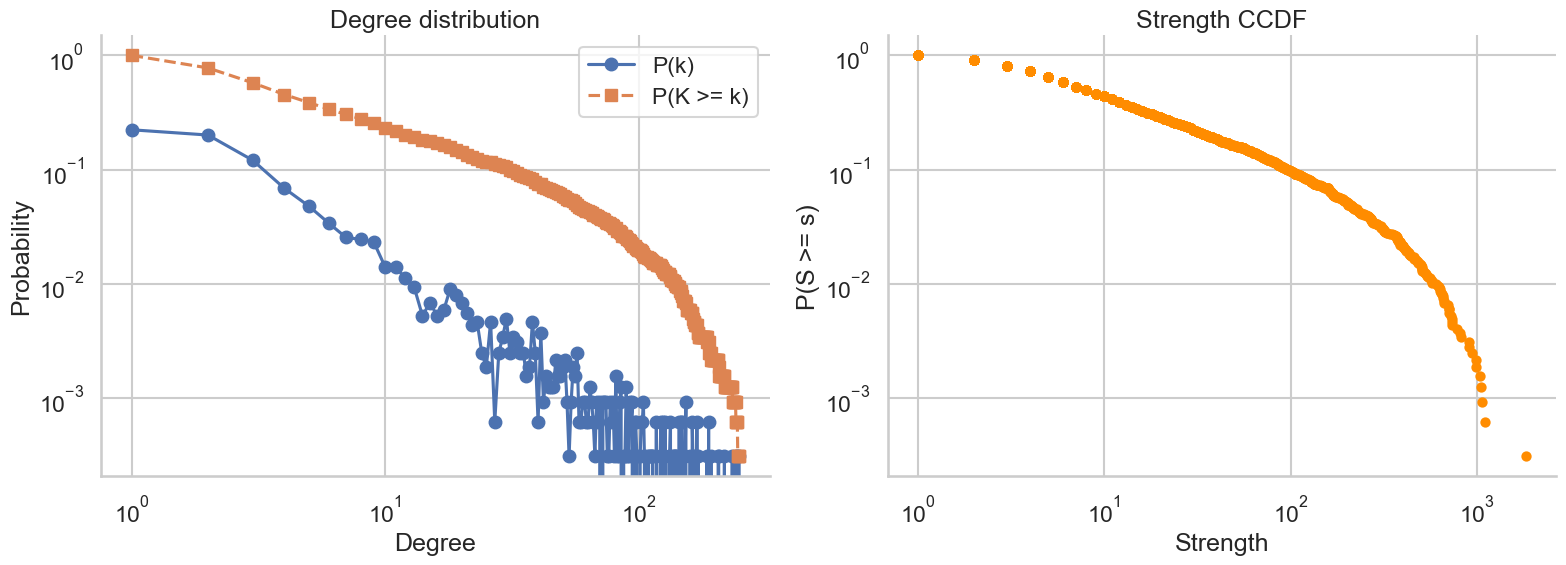

In [12]:
# Visualize the degree distribution and strength CCDF of the undirected graph on a log-log scale.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts = Counter(G_undirected.degree())
degree_values = np.arange(1, max(counts) + 1)
pk = np.array([counts.get(k, 0) / G_undirected.vcount() for k in degree_values])
ccdf = pk[::-1].cumsum()[::-1]

axes[0].loglog(degree_values, pk, marker="o", linestyle="-", label="P(k)")
axes[0].loglog(degree_values, ccdf, marker="s", linestyle="--", label="P(K >= k)")
axes[0].set_title("Degree distribution")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Probability")
axes[0].legend()

strength_sorted = node_metrics["strength"].sort_values()
strength_ccdf = 1 - strength_sorted.rank(method="average", pct=True) + 1 / len(strength_sorted)
axes[1].scatter(strength_sorted.values, strength_ccdf.values, s=35, color="darkorange")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Strength CCDF")
axes[1].set_xlabel("Strength")
axes[1].set_ylabel("P(S >= s)")

plt.tight_layout()
plt.show()

The degree and strength distributions will be fitted to a power-law distribution and then compared with alternative distributions.

In [ ]:
degree_data = np.array(G_undirected.degree())
degree_data = degree_data[degree_data > 0]
strength_data = node_metrics["strength"].to_numpy()
strength_data = strength_data[strength_data > 0]
distributions = {"degree": degree_data, "strength": strength_data}

alternatives = ["lognormal", "exponential", "truncated_power_law", "stretched_exponential"]
fits, fit_rows, lr_rows = {}, [], []
for name, data in distributions.items():
    f = powerlaw.Fit(data, discrete=True, xmin=None, verbose=False)
    fits[name] = f
    fit_rows.append({"variable": name, "x_min": f.power_law.xmin,
                     "tail_share": (data >= f.power_law.xmin).mean(),
                     "alpha": f.power_law.alpha, "sigma": f.power_law.sigma,
                     "KS_D": f.power_law.D})
    for alt in alternatives:
        R, p = f.distribution_compare("power_law", alt)
        favoured = ("power_law" if R > 0 else alt) if p < 0.05 else "no significant difference"
        lr_rows.append({"variable": name, "alternative": alt, "loglik_ratio_R": round(R, 2),
                        "p_value": p, "favoured": favoured})

fit = fits["degree"]
display(pd.DataFrame(fit_rows).round(3))
display(pd.DataFrame(lr_rows))

,variable,x_min,tail_share,alpha,sigma,KS_D
0,degree,2.0,0.777,1.714,0.014,0.038
1,strength,6.0,0.631,1.681,0.015,0.046


,variable,alternative,loglik_ratio_R,p_value,favoured
0,degree,lognormal,-52.27,1.370579e-12,lognormal
1,degree,exponential,991.78,4.547067e-58,power_law
2,degree,truncated_power_law,-77.88,0.000000e+00,truncated_power_law
3,degree,stretched_exponential,-59.18,1.140891e-13,stretched_exponential
4,strength,lognormal,-29.83,3.192249e-07,lognormal
5,strength,exponential,1037.11,2.111880e-55,power_law
6,strength,truncated_power_law,-56.29,0.000000e+00,truncated_power_law
7,strength,stretched_exponential,-35.44,9.008712e-08,stretched_exponential


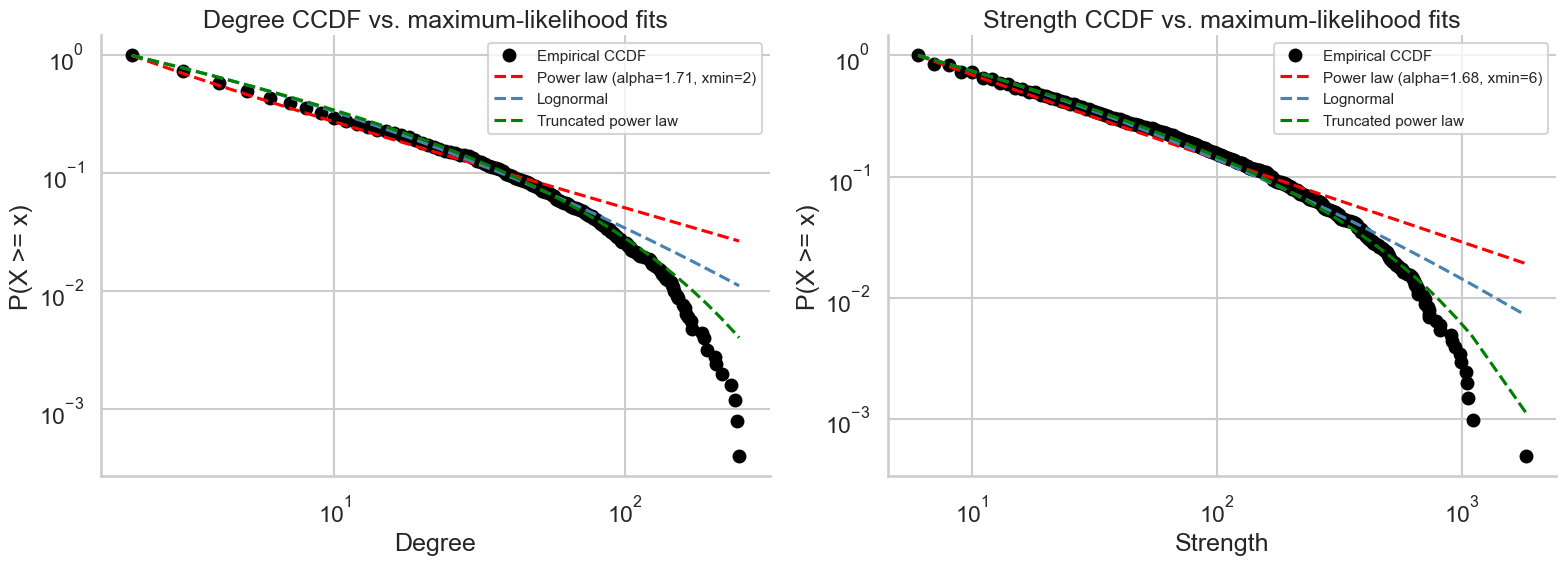

In [44]:
# Visualize the empirical CCDF and the fitted distributions for both degree and strength
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, f) in zip(axes, fits.items()):
    f.plot_ccdf(ax=ax, color="black", marker="o", linewidth=0, label="Empirical CCDF")
    f.power_law.plot_ccdf(ax=ax, color="red", linestyle="--",
                          label=f"Power law (alpha={f.power_law.alpha:.2f}, xmin={f.power_law.xmin:.0f})")
    f.lognormal.plot_ccdf(ax=ax, color="steelblue", linestyle="--", label="Lognormal")
    f.truncated_power_law.plot_ccdf(ax=ax, color="green", linestyle="--", label="Truncated power law")
    ax.set_xlabel(name.capitalize())
    ax.set_ylabel("P(X >= x)")
    ax.set_title(f"{name.capitalize()} CCDF vs. maximum-likelihood fits")
    ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

- The degree distribution and strength CCDF, together with maximum-likelihood fits, indicate that both distributions are heavy-tailed. On log-log axes they decay slowly over two to three orders of magnitude, and a power-law fit to the tail (α = 1.714, x_min = 2 for degree; α = 1.681, x_min = 6 for strength) provides a baseline for comparison. The power law is much preferred over the exponential alternative (R = 991.78, p = 4.5×10⁻⁵⁸ for degree; R = 1037.11, p = 2.1×10⁻⁵⁵ for strength), indicating that the tails decay much more slowly than in a thin-tailed distribution, consistent with the presence of a few highly connected hubs.


- However, a pure power law is rejected, as it is significantly outperformed by the lognormal (degree: R = −52.27, p = 1.4×10⁻¹²; strength: R = −29.83, p = 3.2×10⁻⁷), the stretched exponential (R = −59.18 and −35.44, p < 10⁻⁷), and most strongly the truncated power law (R = −77.88 and −56.29, p < 10⁻¹⁰). 


## 5.3. Centrality Comparison and Airport Importance

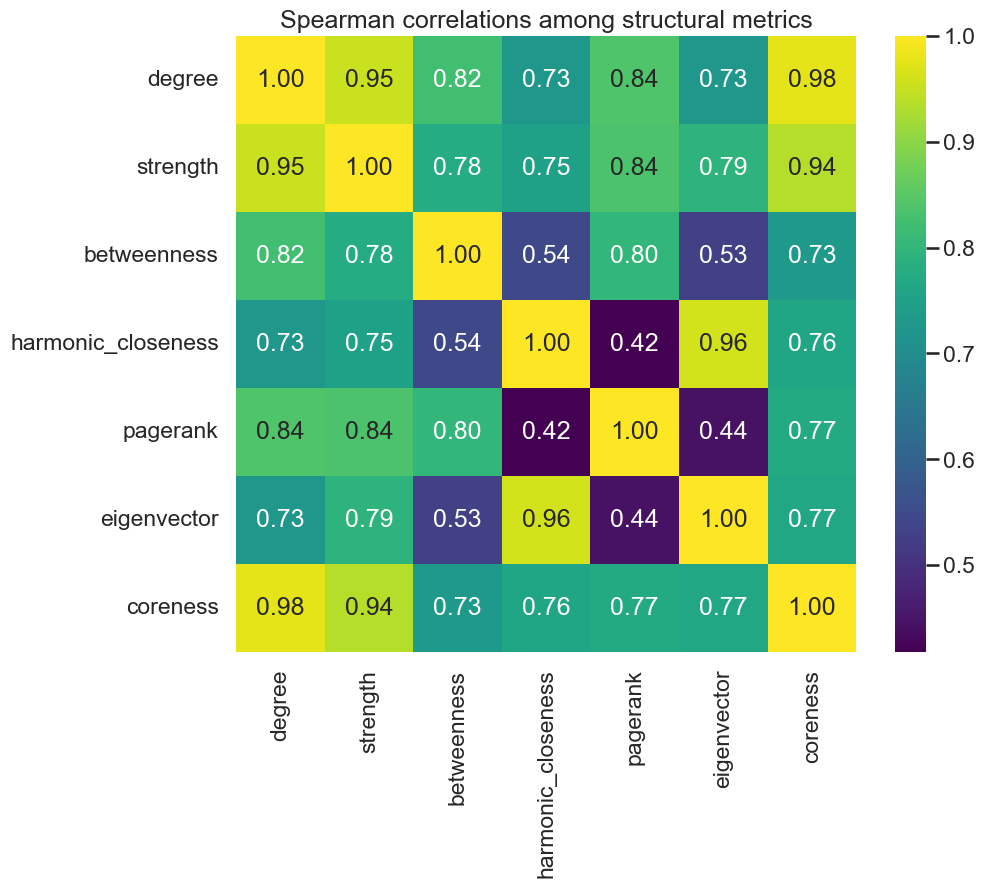

In [15]:
centrality_cols = ["degree", "strength", "betweenness", "harmonic_closeness", "pagerank", "eigenvector", "coreness"]
correlation_matrix = node_metrics[centrality_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Spearman correlations among structural metrics")
plt.show()

- ***Degree***, ***strength***, and ***coreness*** are highly correlated (ρ = 0.94-0.98), suggesting that they capture a similar dimension of airport connectivity.
- ***Harmonic closeness*** and ***eigenvector*** centrality show a very strong correlation (ρ = 0.96), indicating that airports that are topologically close to the rest of the network also tend to be connected to other highly influential airports. Both metrics are moderately to strongly correlated with degree and strength (ρ = 0.73-0.79), suggesting that well-connected airports also tend to occupy relatively central positions in the network.


- ***PageRank*** shows a relatively strong correlation with ***degree*** and ***strength*** (ρ = 0.84 for both), but a much weaker correlation with ***eigenvector*** centrality (ρ = 0.44) despite both being computed on weighted edges. 
- ***Betweenness*** has a mixed correlation pattern. It is strongly correlated with ***degree*** (ρ = 0.82), ***strength*** (ρ = 0.78), and ***PageRank*** (ρ = 0.80), suggesting that highly connected, high-volume airports do tend to serve as important brokers on shortest paths across the network. However, its correlation with ***harmonic closeness*** (ρ = 0.54) and ***eigenvector centrality*** (ρ = 0.53) is much weaker, indicating that being topologically central or connected to other influential hubs is not a strong requirement for having high brokerage importance: an airport can be a critical connecting bridge without occupying a central position in the overall network.

Overall, the correlation structure suggests that these metrics capture different aspects of airport's importance:
- Degree and strength mainly reflect the scale and density of an airport's connections.


- Harmonic closeness and eigenvector centrality provide additional information about how centrally an airport is positioned within the network and its connections to other important hubs.
- Betweenness and PageRank capture additional aspects of brokerage and influence, with betweenness in particular reflecting an airport's role as a connecting bridge. 


### 5.3.1. Major Connectivity Hubs (Strength, Degree)

Major connectivity hubs are identified using two complementary metrics: strength and degree. 
- Strength is used to identify hubs by traffic intensity, reflecting the total number of airline-route entries connecting to and from an airport and indicating how heavily served its connections are.
- Degree, meanwhile, identifies hubs by breadth of reach, indicating how many distinct airports it connects to directly. 

Together, these two rankings capture different dimensions of hub importance: how much traffic an airport handles, and how widely it is connected.

#####  Top 10 airports by `strength`

In [16]:
# Top 10 airports with the highest traffic intensity (most airline-route volume)
node_metrics_hub_strength = node_metrics.sort_values(["strength", "degree"], ascending=False).reset_index(drop=True)
node_metrics_hub_strength.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,216,217,217,1826.0,154186.069782,0.423618,0.009778,1.000000,0.113714,7.0,30,84.439250
1,ORD,Chicago O'Hare International Airport,Chicago,United States,203,206,206,1108.0,240371.198930,0.432755,0.006154,0.744067,0.125219,7.0,30,216.941515
2,PEK,Beijing Capital International Airport,Beijing,China,204,204,205,1061.0,256910.515915,0.436867,0.004971,0.436252,0.123721,7.0,30,242.139977
3,LHR,London Heathrow Airport,London,United Kingdom,170,170,171,1047.0,191427.162370,0.450179,0.005141,0.769277,0.216993,7.0,31,182.833966
4,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
5,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260
6,LAX,Los Angeles International Airport,Los Angeles,United States,147,148,148,986.0,312198.108067,0.434509,0.005879,0.688120,0.184501,7.0,30,316.630941
7,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,185,187,188,936.0,154239.570995,0.419168,0.005642,0.528385,0.125668,7.0,30,164.785866
8,JFK,John F Kennedy International Airport,New York,United States,160,162,162,911.0,129594.202945,0.438669,0.004662,0.706133,0.196994,7.0,31,142.254888
9,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,231,232,248,903.0,263489.111580,0.455123,0.004342,0.440720,0.148328,7.0,31,291.793036



- The 10 airports with the highest strength are major international hubs in North America, Europe, and Asia. 


- While all top-ranked airports have high degree values, strength does not increase proportionally with degree. For example, ATL stands out as the most influential airport in terms of weighted connectivity, with a strength significantly higher than the second-ranked airport, but it has fewer direct connections than Amsterdam (AMS), indicating that many of its routes are served by multiple airlines. 
- Eccentricity is uniformly 7.0 across all top 10 hubs, below the network-wide median of 8. This aligns with these airports' hub role in the network's small-world structure: their extensive direct connections mean they can reach any other airport in the network within a shorter maximum number of steps, compared to a typical, less-connected airport.
- Coreness is consistently high (30–31) across all top 10 hubs, confirming that these airports belong to the network's most densely interconnected core.

##### Top 10 airports by `degree`

In [17]:
# Top 10 airports with the airports with the broadest reach 
node_metrics_hub_degree = node_metrics.sort_values(["degree", "strength"], ascending=False).reset_index(drop=True)
node_metrics_hub_degree.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,231,232,248,903.0,263489.111580,0.455123,0.004342,0.440720,0.148328,7.0,31,291.793036
1,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260
2,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
3,ISL,Atatürk International Airport,Istanbul,Turkey,227,224,233,711.0,218931.245915,0.441727,0.004189,0.247923,0.116287,7.0,31,307.920177
4,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,216,217,217,1826.0,154186.069782,0.423618,0.009778,1.000000,0.113714,7.0,30,84.439250
5,ORD,Chicago O'Hare International Airport,Chicago,United States,203,206,206,1108.0,240371.198930,0.432755,0.006154,0.744067,0.125219,7.0,30,216.941515
6,PEK,Beijing Capital International Airport,Beijing,China,204,204,205,1061.0,256910.515915,0.436867,0.004971,0.436252,0.123721,7.0,30,242.139977
7,MUC,Munich Airport,Munich,Germany,189,191,192,728.0,83832.922375,0.435805,0.003264,0.347347,0.199498,7.0,31,115.155113
8,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,185,187,188,936.0,154239.570995,0.419168,0.005642,0.528385,0.125668,7.0,30,164.785866
9,DME,Domodedovo International Airport,Moscow,Russia,188,187,188,646.0,153139.880984,0.398160,0.004494,0.136962,0.075606,8.0,31,237.058639


In [18]:
# airport hubs that are in the top 10 for both degree and strength

overlap_degree_strength = list(set(node_metrics_hub_degree.head(10).airport.tolist()) & set(node_metrics_hub_strength.head(10).airport.tolist()))
overlap_degree_strength

['CDG', 'ORD', 'FRA', 'PEK', 'ATL', 'AMS', 'DFW']


- Airports ranked by degree largely overlap with the strength-based ranking. ***FRA, ORD, ATL, AMS, CDG, PEK, and DFW appear in both top-10 lists***, confirming these airports are hubs by both measures: broad network reach (many distinct destinations) and high traffic intensity (heavy route volume).


- Three airports appearing in this table that were absent from the top 10 by strength are ISL (Istanbul), MUC (Munich), and DME (Moscow). They have high degree but comparatively lower strength, suggesting these airports serve many distinct destinations but with lower flight frequency per route.
- Domodedovo International Airport (DME) has the highest eccentricity (8.0) among all top-10-by-degree airports, suggesting it sits slightly further from the network's most central core despite its high degree. This is consistent with its more peripheral geographic position.

##### Concentration of connectivity among airports

In [19]:
degrees = np.array(G_undirected.degree())
total_edges = G_undirected.ecount()

sorted_nodes = np.argsort(degrees)[::-1]
percentages = [1, 2, 5, 10]
results = []

for p in percentages:
    n_top = max(1, int(np.ceil(G_undirected.vcount() * p / 100)))

    hub_nodes = set(sorted_nodes[:n_top])

    incident_edges = sum(
        1 for edge in G_undirected.es
        if edge.source in hub_nodes or edge.target in hub_nodes
    )

    hub_share = incident_edges / total_edges

    results.append({
        "Top airports (%)": p,
        "Number of airports": n_top,
        "Incident edges": incident_edges,
        "Hub share": hub_share
    })

hub_concentration = pd.DataFrame(results)

hub_concentration

,Top airports (%),Number of airports,Incident edges,Hub share
0,1,33,5366,0.284548
1,2,65,8330,0.441722
2,5,161,13026,0.690741
3,10,322,15929,0.844681


The network exhibits a strong concentration of connectivity among a small fraction of airports. 
- The top 1% of airports (33 airports) account for 28.5% of all network connections


- The top 2% of airports (65 airports) account for 44.2% of all network connections
- The top 5% of airports (161 airports) account for 69.1% of all network connections
- The top 10% of airports (322 airports) account for 84.5% of all network connections

This indicates that a relatively small set of major airports plays a dominant role in the network's connectivity, which are consistent with a hub-and-spoke structure.

### 5.3.2. Central and Well-Positioned Hubs (eigenvector, harmonic closeness)

Closeness and eigenvector centrality identify airports that are centrally positioned within the network, but from different perspectives. Eigenvector centrality highlights airports connected to other important hubs, while closeness reflects how easily an airport can reach the rest of the network through short paths. Their strong correlation (ρ = 0.96) suggests that these two aspects of centrality are closely related in this network.

##### Top 10 airports by `eigenvector`

In [20]:
node_metrics_eigen = node_metrics.sort_values(["eigenvector", "harmonic_closeness"], ascending=False).reset_index(drop=True)
node_metrics_eigen.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,216,217,217,1826.0,154186.069782,0.423618,0.009778,1.000000,0.113714,7.0,30,84.439250
1,LHR,London Heathrow Airport,London,United Kingdom,170,170,171,1047.0,191427.162370,0.450179,0.005141,0.769277,0.216993,7.0,31,182.833966
2,ORD,Chicago O'Hare International Airport,Chicago,United States,203,206,206,1108.0,240371.198930,0.432755,0.006154,0.744067,0.125219,7.0,30,216.941515
3,JFK,John F Kennedy International Airport,New York,United States,160,162,162,911.0,129594.202945,0.438669,0.004662,0.706133,0.196994,7.0,31,142.254888
4,LAX,Los Angeles International Airport,Los Angeles,United States,147,148,148,986.0,312198.108067,0.434509,0.005879,0.688120,0.184501,7.0,30,316.630941
5,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
6,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,185,187,188,936.0,154239.570995,0.419168,0.005642,0.528385,0.125668,7.0,30,164.785866
7,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260
8,SFO,San Francisco International Airport,San Francisco,United States,104,104,105,499.0,63233.843325,0.407198,0.002746,0.468541,0.266667,7.0,30,126.721129
9,YYZ,Lester B. Pearson International Airport,Toronto,Canada,146,147,147,636.0,228825.555980,0.430812,0.003720,0.457186,0.192060,6.0,30,359.788610


- Atlanta (ATL) has the highest eigenvector centrality (1.0), indicating that it is not only highly connected (top 1 highest strength among airports) but also directly connected to many other influential airports. London Heathrow (LHR), Chicago O’Hare (ORD), and John F Kennedy International Airport (JFK) follow with relatively high eigenvector centrality values (0.769, 0.744, and 0.706).


- Six of the top ten airports are located in the United States (ATL, ORD, JFK, LAX, DFW, and SFO), suggesting a particularly strong influence of the U.S. aviation network on global connectivity.
- The other 4 (LHR, CDG, FRA, YYZ) in the top 10 represent key international gateways linking other continents (Europe and North America) into the network

##### Top 10 airports by `harmonic closeness`

In [21]:
node_metrics_close = node_metrics.sort_values(["harmonic_closeness", "eigenvector"], ascending=False).reset_index(drop=True)
node_metrics_close.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260
1,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
2,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,231,232,248,903.0,263489.111580,0.455123,0.004342,0.440720,0.148328,7.0,31,291.793036
3,LHR,London Heathrow Airport,London,United Kingdom,170,170,171,1047.0,191427.162370,0.450179,0.005141,0.769277,0.216993,7.0,31,182.833966
4,DXB,Dubai International Airport,Dubai,United Arab Emirates,179,185,185,698.0,285897.289541,0.446795,0.004028,0.287193,0.141128,7.0,31,409.594971
5,ISL,Atatürk International Airport,Istanbul,Turkey,227,224,233,711.0,218931.245915,0.441727,0.004189,0.247923,0.116287,7.0,31,307.920177
6,JFK,John F Kennedy International Airport,New York,United States,160,162,162,911.0,129594.202945,0.438669,0.004662,0.706133,0.196994,7.0,31,142.254888
7,PEK,Beijing Capital International Airport,Beijing,China,204,204,205,1061.0,256910.515915,0.436867,0.004971,0.436252,0.123721,7.0,30,242.139977
8,MUC,Munich Airport,Munich,Germany,189,191,192,728.0,83832.922375,0.435805,0.003264,0.347347,0.199498,7.0,31,115.155113
9,LAX,Los Angeles International Airport,Los Angeles,United States,147,148,148,986.0,312198.108067,0.434509,0.005879,0.688120,0.184501,7.0,30,316.630941


In [22]:
# airport hubs that are in the top 10 for both eigenvector centrality and harmonic closeness centrality
overlap_eigen_close = list(set(node_metrics_eigen.head(10).airport.tolist()) & set(node_metrics_close.head(10).airport.tolist()))
overlap_eigen_close

['CDG', 'LAX', 'JFK', 'LHR', 'FRA']

- Frankfurt (FRA) ranks first with a harmonic closeness of 0.4627, followed closely by Paris CDG (0.4604) and Amsterdam AMS (0.4551). These airports are therefore among the most efficiently positioned to reach other airports in the network.


- Unlike eigenvector centrality, which shows a clear dominance of U.S. airports among the top-ranked nodes, harmonic closeness reveals a more geographically balanced structure, with major European and global hubs taking prominent positions. The strong presence of FRA, CDG, AMS, LHR, and MUC suggests that European airports play a key role in facilitating efficient access across the network, connecting different regions through relatively short effective paths.
- Dubai (DXB) and Istanbul (ISL) are also highly ranked despite having lower eigenvector centrality (0.288 and 0.248, respectively). This indicates that they are geographically well positioned to reach many airports, even though their neighbors are not necessarily as influential as those of airports such as LHR or JFK.
- FRA, CDG, LHR, JFK, and LAX appear in both the top 10 for harmonic closeness and eigenvector centrality, indicating that these airports are both well connected to influential hubs and efficiently positioned within the overall network. 

### 5.3.3. Strategic Bridge Hubs (betweenness)

Betweenness identifies airports that play an important bridging role between different parts of the network. A high betweenness score indicates that an airport frequently lies on the shortest paths connecting other airports, highlighting its role as a potential gateway or intermediary.

##### Top 10 airports by `betweeness`

In [23]:

node_metrics_broker = node_metrics.sort_values(["betweenness"], ascending=False).reset_index(drop=True)
node_metrics_broker.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
1,LAX,Los Angeles International Airport,Los Angeles,United States,147,148,148,986.0,312198.108067,0.434509,0.005879,0.688120,0.184501,7.0,30,316.630941
2,ANC,Ted Stevens Anchorage International Airport,Anchorage,United States,34,34,34,118.0,301486.435118,0.325189,0.002649,0.035820,0.096257,8.0,10,2554.969789
3,DXB,Dubai International Airport,Dubai,United Arab Emirates,179,185,185,698.0,285897.289541,0.446795,0.004028,0.287193,0.141128,7.0,31,409.594971
4,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260
5,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,231,232,248,903.0,263489.111580,0.455123,0.004342,0.440720,0.148328,7.0,31,291.793036
6,PEK,Beijing Capital International Airport,Beijing,China,204,204,205,1061.0,256910.515915,0.436867,0.004971,0.436252,0.123721,7.0,30,242.139977
7,ORD,Chicago O'Hare International Airport,Chicago,United States,203,206,206,1108.0,240371.198930,0.432755,0.006154,0.744067,0.125219,7.0,30,216.941515
8,YYZ,Lester B. Pearson International Airport,Toronto,Canada,146,147,147,636.0,228825.555980,0.430812,0.003720,0.457186,0.192060,6.0,30,359.788610
9,ISL,Atatürk International Airport,Istanbul,Turkey,227,224,233,711.0,218931.245915,0.441727,0.004189,0.247923,0.116287,7.0,31,307.920177


In [24]:
# airport hubs that are in the top 10 for both strength and betweenness centrality
overlap_strength_betweenness = list(set(node_metrics_hub_strength.head(10).airport.tolist()) & set(node_metrics_broker.head(10).airport.tolist()))
overlap_strength_betweenness

['CDG', 'LAX', 'ORD', 'FRA', 'PEK', 'AMS']

- Charles de Gaulle Airport (CDG) has the highest betweenness centrality, indicating that it is the most important broker in the network and lies on the largest number of shortest paths between other airports.


- The top-ranked airports are major intercontinental hubs, including Los Angeles (LAX), Paris (CDG), Frankfurt (FRA), Amsterdam (AMS), Dubai (DXB), Beijing (PEK), and Chicago (ORD). These airports play a crucial role in connecting different geographical regions.
- Dubai International Airport (DXB) exhibits exceptionally high betweenness despite having fewer direct connections than several European hubs. This highlights its strategic role as a gateway between Europe, Asia, Africa, and Oceania.
- **Anchorage  International Airport (ANC) is an outstanding example of a smaller airport acting as a strategic gateway rather than a high-traffic hub**. Although it has only 34 direct connections and a relatively low coreness (10), it ranks third in betweenness centrality. Its betweenness_per_tie is extremely high (2554.97, roughly six to twelve times higher than any other airport in the list), indicating that each of its direct connections contributes disproportionately to maintaining shortest-path connectivity across the network. ANC functions as a critical bridge connecting otherwise distant parts of the network.
- 6 out of 10 airports in this list overlap with the top 10 by strength (FRA, ORD, AMS, LAX, CDG, PEK), suggesting that high traffic volume generally supports a strong brokerage role. However, this relationship is not absolute in either direction. ANC shows that strategic positioning alone can drive high betweenness without high traffic volume, while ATL, despite topping the network in both strength and eigenvector centrality, doesn't appear in the top 10 betweenness list, confirming that connectivity and influence don't automatically translate into lying on the network's shortest paths.

### 5.3.4. Influential Hubs (PageRank)

PageRank identifies airports that have high overall importance within the network by considering both their connections and the importance of the airports they connect to. An airport with high PageRank means that it is highly influential in the network, particularly because it is connected to other important airports.

##### Top 10 airports by `PageRank`

In [25]:

node_metrics_pagerank = node_metrics.sort_values(["pagerank"], ascending=False).reset_index(drop=True)
node_metrics_pagerank.head(10)

,airport,name,city,country,in_degree,out_degree,degree,strength,betweenness,harmonic_closeness,pagerank,eigenvector,local_clustering,eccentricity,coreness,betweenness_per_tie
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,216,217,217,1826.0,154186.069782,0.423618,0.009778,1.000000,0.113714,7.0,30,84.439250
1,ORD,Chicago O'Hare International Airport,Chicago,United States,203,206,206,1108.0,240371.198930,0.432755,0.006154,0.744067,0.125219,7.0,30,216.941515
2,LAX,Los Angeles International Airport,Los Angeles,United States,147,148,148,986.0,312198.108067,0.434509,0.005879,0.688120,0.184501,7.0,30,316.630941
3,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,185,187,188,936.0,154239.570995,0.419168,0.005642,0.528385,0.125668,7.0,30,164.785866
4,CDG,Charles de Gaulle International Airport,Paris,France,233,237,240,1041.0,327988.109177,0.460383,0.005162,0.583015,0.144212,7.0,31,315.070230
5,LHR,London Heathrow Airport,London,United Kingdom,170,170,171,1047.0,191427.162370,0.450179,0.005141,0.769277,0.216993,7.0,31,182.833966
6,SIN,Singapore Changi Airport,Singapore,Singapore,124,124,124,814.0,158583.323493,0.404392,0.004992,0.304355,0.175321,8.0,25,194.819808
7,PEK,Beijing Capital International Airport,Beijing,China,204,204,205,1061.0,256910.515915,0.436867,0.004971,0.436252,0.123721,7.0,30,242.139977
8,DEN,Denver International Airport,Denver,United States,167,168,169,733.0,134216.745208,0.391950,0.004925,0.427005,0.129473,7.0,30,183.106064
9,FRA,Frankfurt am Main Airport,Frankfurt,Germany,238,239,244,990.0,270552.407016,0.462681,0.004719,0.526667,0.146968,7.0,31,273.285260


In [26]:
# airport hubs that are in the top 10 for both PageRank and strength
overlap_pagerank_strength = list(set(node_metrics_hub_strength.head(10).airport.tolist()) & set(node_metrics_pagerank.head(10).airport.tolist()))
overlap_pagerank_strength

['CDG', 'LAX', 'ORD', 'LHR', 'FRA', 'PEK', 'ATL', 'DFW']

In [27]:
# airport hubs that are in the top 10 for both PageRank and eigenvector centrality
overlap_pagerank_eigen = list(set(node_metrics_pagerank.head(10).airport.tolist()) & set(node_metrics_eigen.head(10).airport.tolist()))
overlap_pagerank_eigen

['CDG', 'LAX', 'ORD', 'LHR', 'FRA', 'ATL', 'DFW']

- The top 10 by PageRank overlaps substantially with the top 10 by strength (8 out of 10 airports). The two exceptions are Denver (DEN) and Singapore (SIN): both airports have relatively modest strength and degree compared to other top-ranked hubs, yet achieve high PageRank, suggesting they receive disproportionately influential incoming connections. 


- Singapore has a higher eccentricity (8.0) and lower coreness (25) than any other airport in this list, indicating that its high PageRank stems from its unique gateway role linking Southeast Asia to major global hubs, rather than from occupying the network's most central or densely-connected position.
- Although PageRank and eigenvector centrality show a moderate overall correlation (ρ=0.44) across the full network, their top 10 rankings overlap substantially, with 7 out of 10 airports in common. This apparent discrepancy can be explained by the fact that the correlation captures agreement across the entire network, including many smaller and less-connected airports where the two metrics may diverge considerably. In contrast, the high overlap among the top-ranked airports may reflect a ceiling effect, whereby both metrics consistently identify the network’s largest and most influential hubs, even though their exact rankings may differ.

# 6. Assortativity and Mixing patterns

In Section 3.2, it has been reported that `G_undirected` has the **degree assortativity close to zero (-0.017)**, suggesting well-connected hub airports are no more (or less) likely to connect to other hubs than chance would suggest. In this section, the k_nn(k) curve, which represents average degree of the neighbors of nodes with degree k, will be examined to test whether this near-zero coefficient truly reflects an absence of degree-based mixing, or whether it instead conceals opposing assortative and disassortative tendencies at different degree scales that cancel out in the global average.

Moreover, other aspects of assortativity are examined to provide further insights:

- **Nominal assortativity by country**: Do airports tend to connect to airports in the same country?
- **Scalar assortativity by time zone**: Do airports tend to connect to airports with similar time zones (which may partially reflect regional or geographic proximity)?

These two assortativity measures examine whether airport connectivity is structured according to national boundaries, and geographic proximity, respectively.

## 6.1. Degree-Based Mixing: k_nn(k) Curve

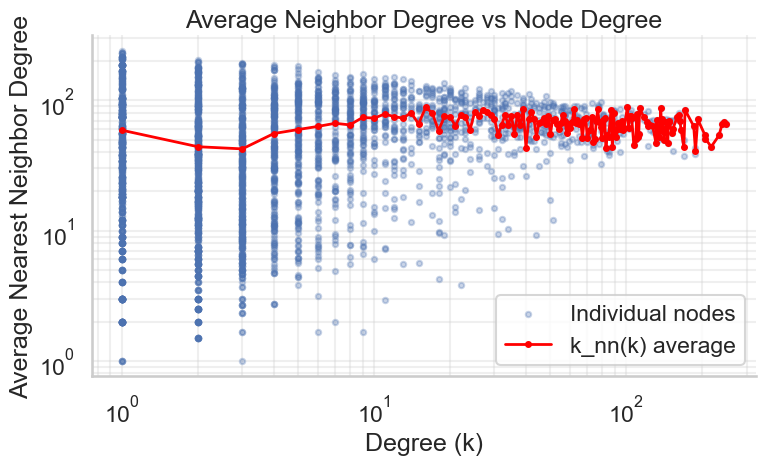

In [28]:
knn, knnk = G_undirected.knn()
degrees = G_undirected.degree()

df_knn = pd.DataFrame({"degree": degrees, "knn": knn})

k_values = np.arange(1, len(knnk) + 1)
knnk_series = pd.Series(knnk, index=k_values)
knnk_clean = knnk_series.dropna()

plt.figure(figsize=(8, 5))
plt.scatter(df_knn["degree"], df_knn["knn"], alpha=0.3, s=15, label="Individual nodes")
plt.plot(knnk_clean.index, knnk_clean.values, color="red", linewidth=2, marker="o", markersize=4, label="k_nn(k) average")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (k)")
plt.ylabel("Average Nearest Neighbor Degree")
plt.title("Average Neighbor Degree vs Node Degree")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

As average neighbor degree is quite noisy across individual nodes, logarithmic binning with bootstrap confidence intervals is used to reveal the underlying trend and its uncertainty

In [29]:
# Logarithmic binning of k_nn(k) with bootstrap confidence intervals
rng = np.random.default_rng(RANDOM_SEED)

degrees_arr = np.array(G_undirected.degree())
knn_arr, _ = G_undirected.knn()
knn_arr = np.array(knn_arr)

valid_mask = ~np.isnan(knn_arr) & (degrees_arr > 0)
deg_valid = degrees_arr[valid_mask]
knn_valid = knn_arr[valid_mask]

# Log-spaced bin edges spanning the observed degree range
n_bins = 14
log_edges = np.unique(
    np.round(np.logspace(np.log10(deg_valid.min()), np.log10(deg_valid.max()), n_bins + 1)).astype(int)
)
log_edges[-1] += 1  # make the rightmost edge inclusive of the maximum degree


def bootstrap_mean_ci(values, n_boot=5000, ci=95, seed=RANDOM_SEED):
    """Bootstrap the mean and a percentile confidence interval for a 1-D array."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        return values[0], values[0], values[0]
    rng_local = np.random.default_rng(seed)
    boot_means = rng_local.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return values.mean(), lo, hi


rows = []
for i in range(len(log_edges) - 1):
    lo_edge, hi_edge = log_edges[i], log_edges[i + 1]
    bin_mask = (deg_valid >= lo_edge) & (deg_valid < hi_edge)
    n_nodes = int(bin_mask.sum())
    if n_nodes == 0:
        continue
    vals = knn_valid[bin_mask]
    mean_knn, ci_lo, ci_hi = bootstrap_mean_ci(vals)
    rows.append({
        "k_min": int(lo_edge), "k_max": int(hi_edge - 1),
        "k_center": float(np.sqrt(lo_edge * (hi_edge - 1))) if hi_edge - 1 > 0 else float(lo_edge),
        "n_nodes": n_nodes, "mean_knn": mean_knn,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
    })

binned_knn = pd.DataFrame(rows)
binned_knn


,k_min,k_max,k_center,n_nodes,mean_knn,ci_lo,ci_hi
0,1,1,1.000000,718,58.948468,54.946936,63.002890
1,2,2,2.000000,646,44.045666,40.562577,47.533378
2,3,4,3.464102,610,47.188798,43.880068,50.745830
3,5,6,5.477226,263,61.125349,56.074132,66.243356
4,7,10,8.366600,281,69.088241,64.839713,73.416680
5,11,15,12.845233,150,74.928403,69.178256,80.804716
6,16,22,18.761663,145,72.737960,67.671156,77.844126
7,23,34,27.964263,118,71.912734,66.947604,76.848828
8,35,50,41.833001,99,69.295291,65.133427,73.573702
9,51,75,61.846584,75,66.931569,62.972144,70.652779


To test whether the observed degree correlations reflect genuine mixing patterns rather than a by-product of the degree distribution: 
- A degree-preserving null model is created by randomly rewiring the edges of the undirected network (10 × the number of edges per realisation, repeated 200 times), so that every airport keeps its exact degree and the graph remains simple. It is used instead of the configuration model with simplify() because rewiring guarantees that each airport stays in its original degree bin. Meanwhile, removing self-loops and multi-edges after the configuration model would alter some degrees, especially those of hubs, and shift nodes across bins. 


- The binned k_nn(k) and the degree assortativity of the empirical network are compared with the null distribution (mean, 95% range, and z-score for each bin) to determine whether the observed mixing pattern differs significantly from what the degree distribution alone would produce.
- To test whether the three regimes suggested by the k_nn(k) curve (low-degree dip, mid-degree rise, high-degree decline) are genuine, k_nn is contrasted between the endpoints of each regime (k = 1 vs 2, k ≈ 3 vs k ≈ 20, k ≈ 20 vs the top bin). Each difference is given a bootstrap confidence interval (5,000 resamples) and compared with the 95% range of the same difference across the 200 rewired networks.

In [ ]:
# Random-graph null model for k_nn(k) and degree assortativity
ig.set_random_number_generator(random.Random(RANDOM_SEED))
N_NULL = 200
bin_masks = [(deg_valid >= r.k_min) & (deg_valid <= r.k_max) for r in binned_knn.itertuples()]

null_knn = np.empty((N_NULL, len(binned_knn)))
null_assortativity = np.empty(N_NULL)
for s in range(N_NULL):
    g_null = G_undirected.copy()
    g_null.rewire(n=10 * g_null.ecount())
    knn_null = np.array(g_null.knn()[0])[valid_mask]
    null_knn[s] = [knn_null[m].mean() for m in bin_masks]
    null_assortativity[s] = g_null.assortativity_degree(directed=False)

binned_knn["null_mean"] = null_knn.mean(axis=0)
binned_knn["null_lo"], binned_knn["null_hi"] = np.percentile(null_knn, [2.5, 97.5], axis=0)
binned_knn["z_vs_null"] = (binned_knn["mean_knn"] - binned_knn["null_mean"]) / null_knn.std(axis=0, ddof=1)
display(binned_knn.drop(columns="k_center").round(2))

print(f"Degree assortativity: empirical = {G_undirected.assortativity_degree(directed=False):.3f}, "
      f"null = {null_assortativity.mean():.3f} (95% range {np.percentile(null_assortativity, 2.5):.3f} "
      f"to {np.percentile(null_assortativity, 97.5):.3f})")

,k_min,k_max,n_nodes,mean_knn,ci_lo,ci_hi,null_mean,null_lo,null_hi,z_vs_null
0,1,1,718,58.95,54.95,63.00,72.21,68.01,76.72,-5.90
1,2,2,646,44.05,40.56,47.53,71.94,69.00,75.99,-15.37
2,3,4,610,47.19,43.88,50.75,71.94,69.36,74.64,-17.67
3,5,6,263,61.13,56.07,66.24,71.95,68.73,74.93,-6.56
4,7,10,281,69.09,64.84,73.42,71.36,69.09,73.76,-1.81
5,11,15,150,74.93,69.18,80.80,70.88,68.03,73.73,2.86
6,16,22,145,72.74,67.67,77.84,69.87,67.40,72.20,2.46
7,23,34,118,71.91,66.95,76.85,68.66,66.68,70.74,3.19
8,35,50,99,69.30,65.13,73.57,67.19,65.86,68.93,2.47
9,51,75,75,66.93,62.97,70.65,64.91,63.33,66.28,2.51


Degree assortativity: empirical = -0.017, null = -0.099 (95% range -0.110 to -0.088)


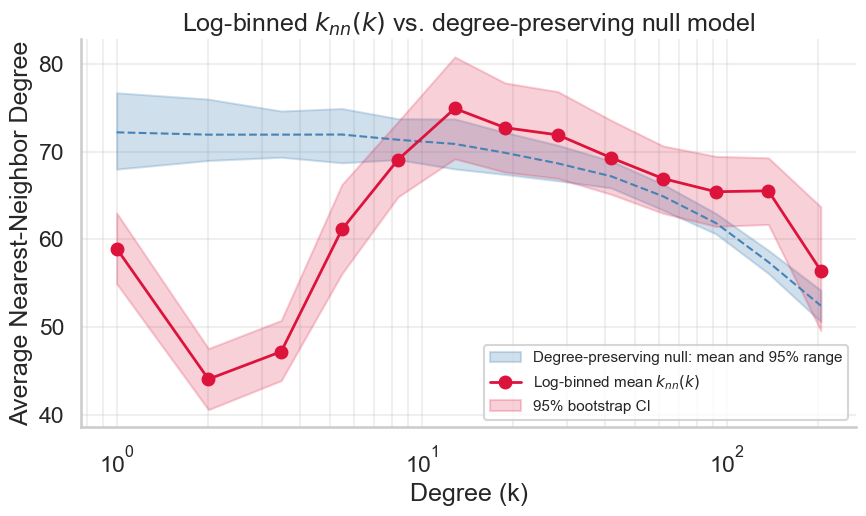

In [46]:
# Visualize the log-binned k_nn(k) with bootstrap confidence intervals and the degree-preserving null model
plt.figure(figsize=(9, 5.5))
plt.fill_between(binned_knn["k_center"], binned_knn["null_lo"], binned_knn["null_hi"],
                 color="steelblue", alpha=0.25, label="Degree-preserving null: mean and 95% range")
plt.plot(binned_knn["k_center"], binned_knn["null_mean"], color="steelblue", linestyle="--", linewidth=1.5)
plt.plot(binned_knn["k_center"], binned_knn["mean_knn"], color="crimson", marker="o",
         linewidth=2, label="Log-binned mean $k_{nn}(k)$")
plt.fill_between(binned_knn["k_center"], binned_knn["ci_lo"], binned_knn["ci_hi"],
                  color="crimson", alpha=0.2, label="95% bootstrap CI")
plt.xscale("log")
plt.xlabel("Degree (k)")
plt.ylabel("Average Nearest-Neighbor Degree")
plt.title("Log-binned $k_{nn}(k)$ vs. degree-preserving null model")
plt.legend(fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Contrast k_nn between two degree bins: observed difference + bootstrap CI vs. the same difference in the rewired null.
def bin_of(k):
    return int(np.flatnonzero((binned_knn["k_min"] <= k) & (binned_knn["k_max"] >= k))[0])


def bin_label(b):
    k_min, k_max = int(binned_knn.loc[b, "k_min"]), int(binned_knn.loc[b, "k_max"])
    return f"k={k_min}" if k_min == k_max else f"k={k_min}-{k_max}"


def contrast(k_a, k_b, n_boot=5000, seed=RANDOM_SEED):
    a, b = bin_of(k_a), bin_of(k_b)
    va, vb = knn_valid[bin_masks[a]], knn_valid[bin_masks[b]]
    rng_local = np.random.default_rng(seed)
    boot = (rng_local.choice(vb, (n_boot, len(vb))).mean(axis=1)
            - rng_local.choice(va, (n_boot, len(va))).mean(axis=1))
    null_diff = null_knn[:, b] - null_knn[:, a]
    return {"comparison": f"{bin_label(a)} -> {bin_label(b)}", "diff": vb.mean() - va.mean(),
            "boot_ci_lo": np.percentile(boot, 2.5), "boot_ci_hi": np.percentile(boot, 97.5),
            "null_diff": null_diff.mean(),
            "null_lo": np.percentile(null_diff, 2.5), "null_hi": np.percentile(null_diff, 97.5)}


knn_contrasts = pd.DataFrame([
    {"feature": "low-degree dip", **contrast(1, 2)},
    {"feature": "mid-degree rise", **contrast(3, 20)},
    {"feature": "high-degree decline", **contrast(20, int(deg_valid.max()))},
])
display(knn_contrasts.round(2))
print(f"Structural cut-off sqrt(<k> N) = {np.sqrt(deg_valid.mean() * len(deg_valid)):.0f}")

,feature,comparison,diff,boot_ci_lo,boot_ci_hi,null_diff,null_lo,null_hi
0,low-degree dip,k=1 -> k=2,-14.90,-20.43,-9.32,-0.26,-5.95,5.37
1,mid-degree rise,k=3-4 -> k=16-22,25.55,19.38,31.58,-2.07,-6.14,1.41
2,high-degree decline,k=16-22 -> k=167-248,-16.30,-24.98,-7.24,-17.44,-20.63,-14.48


Structural cut-off sqrt(<k> N) = 194


Overall, the k_nn(k) curve is non-monotonic: it falls from k = 1 to k = 2, rises through the mid-degree range, and falls again at the highest degrees. The first two trends are genuine mixing patterns, whereas the last is largely a structural consequence of the degree sequence:


- ***The low-degree dip is real***: k_nn drops by 14.90 (bootstrap 95% CI −20.43 to −9.32), whereas the rewired null produces almost no change (−0.26, 95% range −5.95 to 5.37).
- ***The mid-degree rise is real*** and the strongest effect: k_nn increases by 25.55 from k = 3-4 to k = 16-22 (CI 19.38 to 31.58), while the null gives a slight decrease (−2.07, range −6.14 to 1.41).
- ***The high-degree decline is structural***, not a genuine mixing pattern: k_nn falls by 16.30 from k = 16-22 to k = 167-248 (CI −24.98 to −7.24), and the rewired null produces almost the same fall (−17.44, range −20.63 to −14.48).

Therefore, **the near-zero degree assortativity (r = -0.017) does not reflect an absence of degree-based mixing**. Instead, it conceals opposing tendencies at different degree scales, a dip at low degrees and a rise at mid degrees, which largely cancel out in the global average.

## 6.2. Country and Time Zone Assortativity

In [32]:
print("Missing country:", pd.Series(G_undirected.vs["country"]).isna().sum())
print("Missing timezone:", pd.Series(G_undirected.vs["timezone"]).isna().sum())

Missing country: 0
Missing timezone: 0


In [33]:
country_codes = pd.Series(G_undirected.vs["country"]).factorize()[0].tolist()
r_country = G_undirected.assortativity_nominal(country_codes, directed=False)

timezone = pd.to_numeric(pd.Series(G_undirected.vs["timezone"]), errors="coerce")
timezone_filled = timezone.fillna(timezone.mean()).tolist()
r_timezone = G_undirected.assortativity(timezone_filled, directed=False)


attribute_assortativity = pd.DataFrame([
    {"attribute": "country", "type": "nominal", "assortativity": r_country},
    {"attribute": "timezone", "type": "scalar", "assortativity": r_timezone},
]).round(4)
attribute_assortativity

,attribute,type,assortativity
0,country,nominal,0.4448
1,timezone,scalar,0.9055


- Country assortativity (nominal, 0.445) is moderately strong and positive. This indicates that airports connect to other airports in the same country far more than random mixing would predict. 


- Timezone assortativity (scalar, 0.906) is very strongly positive, and higher than the country-level figure. Since timezone is essentially a coarse proxy for longitude, this quantifies the same pattern already visible in the geographic plot at 4.2: most connections are concentrated among geographically nearby airports. 
- Overall, geography and national boundaries are the more straightforward organizing factors of the network, while connectivity still plays a real but scale-dependent role.

# 7. Small-world properties: Comparison with random-graph null models

From Section 3.2, the network exhibits relatively high clustering (global = 0.25; average local = 0.49) and short path lengths (average = 3.96 hops; diameter = 12 hops), suggesting a small world pattern characterized by tightly connected neighborhoods and short distances between airports. This section tests this hypothesis against suitable null models to determine whether the observed clustering and path lengths are significantly different from what would be expected by chance.

Two null models used are:
- **Erdős–Rényi / Gilbert model** `G(n, p)` to test whether the observed small-world characteristics can be explained by random connectivity alone, with edges placed independently while preserving the same number of nodes and approximately the same edge density.
- **Configuration model** to test whether the observed pattern can be explained by random connectivity given the network's degree sequence, thereby controlling for the heterogeneous degree structure of the airport network.

Both models are generated 20 times to obtain distributions of the expected network properties rather than relying on a single potentially noisy random realization.

To ensure an apples-to-apples comparison, the analysis uses the giant component of `G_undirected` and the same unweighted, hop-based metrics as in Section 3.2. Both null models are generated as undirected graphs, consistent with this network representation.

In [34]:
ig.set_random_number_generator(random.Random(42))

N_SAMPLES = 20

giant_und = G_undirected.components().giant()
n_g, m_g = giant_und.vcount(), giant_und.ecount()
p_er = m_g / (n_g * (n_g - 1) / 2)
degree_seq = giant_und.degree()

empirical = {
    "clustering": giant_und.transitivity_undirected(),
    "avg_path_length": giant_und.average_path_length(),
}

er_clustering, er_apl = [], []
for _ in range(N_SAMPLES):
    g_er = ig.Graph.Erdos_Renyi(n=n_g, p=p_er)
    er_clustering.append(g_er.transitivity_undirected())
    if g_er.is_connected():
        er_apl.append(g_er.average_path_length())

cm_clustering, cm_apl = [], []
for _ in range(N_SAMPLES):
    g_cm = ig.Graph.Degree_Sequence(degree_seq, method="configuration")
    g_cm.simplify()
    cm_clustering.append(g_cm.transitivity_undirected())
    if g_cm.is_connected():
        cm_apl.append(g_cm.average_path_length())
    else:
        g_cm_giant = g_cm.components().giant()
        cm_apl.append(g_cm_giant.average_path_length())

null_model_summary = pd.DataFrame([
    {"model": "Empirical", "clustering": empirical["clustering"], "clustering_std": np.nan,
     "avg_path_length": empirical["avg_path_length"], "avg_path_length_std": np.nan,
     "n_samples": 1},
    {"model": "Erdos-Renyi G(n,p)", "clustering": np.mean(er_clustering), "clustering_std": np.std(er_clustering),
     "avg_path_length": np.mean(er_apl), "avg_path_length_std": np.std(er_apl),
     "n_samples": len(er_apl)},
    {"model": "Configuration model", "clustering": np.mean(cm_clustering), "clustering_std": np.std(cm_clustering),
     "avg_path_length": np.mean(cm_apl), "avg_path_length_std": np.std(cm_apl),
     "n_samples": len(cm_apl)},
]).round(4)
null_model_summary

,model,clustering,clustering_std,avg_path_length,avg_path_length_std,n_samples
0,Empirical,0.2497,NaN,3.9585,NaN,1
1,"Erdos-Renyi G(n,p)",0.0037,0.0002,3.5482,0.0057,20
2,Configuration model,0.0783,0.0013,3.3212,0.0073,20


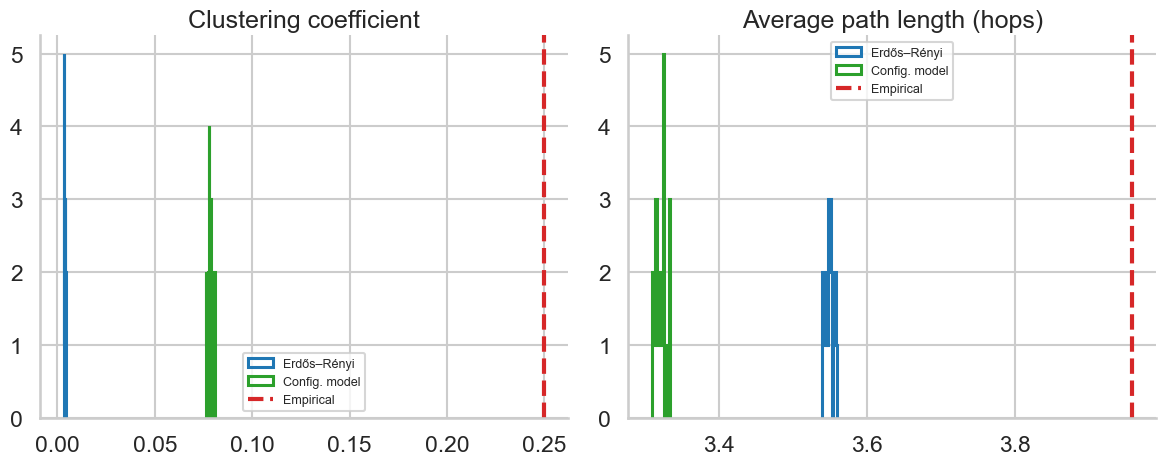

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

panels = [
    (er_clustering, cm_clustering, empirical["clustering"], "Clustering coefficient", axes[0]),
    (er_apl, cm_apl, empirical["avg_path_length"], "Average path length (hops)", axes[1]),
]

for er_vals, cm_vals, emp_val, title, ax in panels:
    ax.hist(er_vals, bins=12, histtype="step", linewidth=2.2, color="tab:blue", label="Erdős–Rényi")
    ax.hist(cm_vals, bins=12, histtype="step", linewidth=2.2, color="tab:green", label="Config. model")
    ax.axvline(emp_val, color="tab:red", linewidth=3, linestyle="--", label="Empirical")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [36]:

C_real = empirical["clustering"]
L_real = empirical["avg_path_length"]

C_rand_er = np.mean(er_clustering)
L_rand_er = np.mean(er_apl)

C_rand_cm = np.mean(cm_clustering)
L_rand_cm = np.mean(cm_apl)

# calculate sigma against the Erdős-Rényi model
sigma_er = (C_real / C_rand_er)  / (L_real / L_rand_er)

# calculate sigma against the configuration model
sigma_cm = (C_real / C_rand_cm)  / (L_real / L_rand_cm)

print(f"Sigma (against Erdős-Rényi Model) = {sigma_er:.4f}")
print(f"Sigma (against Configuration Model) = {sigma_cm:.4f}")

Sigma (against Erdős-Rényi Model) = 60.5898
Sigma (against Configuration Model) = 2.6747


- The empirical network has a clustering coefficient of 0.2497, much higher than both the Erdős–Rényi model (0.0037) and the Configuration model (0.0783), meaning that the high clustering cannot be explained by random connectivity or degree structure alone. This suggests that nodes in the network genuinely tend to form tightly closed groups.


- The empirical average path length is 3.96, only 12% and 19% higher than the ER and Configuration model baselines respectively. This increase in average path length is modest compared with the much larger increases in clustering (67× and 3.2×, respectively). This indicates that, despite its high clustering, the network still maintains short paths between nodes, providing further evidence of small-world behavior.
- The small-world coefficient computed against the Erdos-Rényi baseline is very high (σ = 60.59), suggesting strong small-world characteristics. However, this metric can be inflated by degree heterogeneity. After eliminating this confounding effect by using the Configuration model as baseline, sigma remains above 1 (σ = 2.67), confirming that the network retains genuine small-world properties beyond what is explained by its degree distribution alone. 

Based on these evidences, it can be concluded that ***the network exhibits small-world characteristics***

# 8. Community detection

## 8.1. Algorithm Screening: Stability & Effectiveness Test

In this section, four community detection algorithms (Louvain, Walktrap, Infomap, and Label Propagation) are each run 50 times on the network to evaluate both their effectiveness and stability before selecting the algorithm for the main analysis.

3 metrics are used to evaluate the effectiveness and stability are: 

- Q (modularity): quantifies how strong and well-separated the detected community structure is. Higher values indicate a stronger community structure.
- NMI stability: measures the similarity between partitions produced across different runs. Values closer to 1 indicate that the algorithm consistently produces the same community assignments.
- ARI stability: measures the agreement between partitions across different runs, correcting for chance. Values closer to 1 indicate higher consistency in the detected partitions.

In addition, the mean and standard deviation of the number of communities detected (Communities_mean / Communities_std) across runs are reported to capture how consistent each algorithm is in determining the number of communities.

In [37]:
ig.set_random_number_generator(random.Random(42))

G_comm = G_undirected.components().giant()
N_RUNS = 50

ALGORITHMS = ['Louvain', 'Walktrap', 'Infomap', 'Label Propagation']


def run_algorithm(name):
    if name == 'Louvain':
        return G_comm.community_multilevel(weights='weight')
    elif name == 'Walktrap':
        return G_comm.community_walktrap(steps=4, weights='weight').as_clustering()
    elif name == 'Infomap':
        return G_comm.community_infomap(edge_weights='weight')
    elif name == 'Label Propagation':
        return G_comm.community_label_propagation(weights='weight')


def compute_pairwise_stability(partitions, n_runs):
    nmi_scores, ari_scores = [], []

    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            nmi_scores.append(NMI(partitions[i], partitions[j]))
            ari_scores.append(ARI(partitions[i], partitions[j]))

    return nmi_scores, ari_scores


all_results = {}
results = []

for name in ALGORITHMS:
    # Run algorithm N_RUNS times and collect partitions
    partitions = [run_algorithm(name).membership for _ in range(N_RUNS)]
    all_results[name] = partitions

    # Effectiveness metrics
    n_communities = [len(set(m)) for m in partitions]
    modularities = [G_comm.modularity(m, weights='weight') for m in partitions]

    # Stability metrics
    nmi_scores, ari_scores = compute_pairwise_stability(partitions, N_RUNS)

    results.append({
        'Algorithm': name,
        'Communities_mean': np.mean(n_communities),
        'Communities_std': np.std(n_communities),
        'Q_mean': np.mean(modularities),
        'Q_std': np.std(modularities),
        'NMI_stability': np.mean(nmi_scores),
        'NMI_stability_std': np.std(nmi_scores),
        'ARI_stability': np.mean(ari_scores),
        'ARI_stability_std': np.std(ari_scores),
    })

results_df = pd.DataFrame(results).round(4).sort_values("Q_mean", ascending=False).reset_index(drop=True)
results_df

,Algorithm,Communities_mean,Communities_std,Q_mean,Q_std,NMI_stability,NMI_stability_std,ARI_stability,ARI_stability_std
0,Louvain,17.24,0.8139,0.6525,0.0011,0.9224,0.0266,0.8895,0.0438
1,Infomap,119.20,3.0919,0.6165,0.0019,0.9700,0.0071,0.9381,0.0264
2,Walktrap,208.00,0.0000,0.6010,0.0000,1.0000,0.0000,1.0000,0.0000
3,Label Propagation,61.52,5.9841,0.5816,0.0785,0.8130,0.0724,0.6421,0.1778


From the effectiveness and stability analysis, it can be observed that:

- Louvain has the highest Q (≈ 0.65) and good stability (ARI ≈ 0.89).


- Infomap provides a good balance between relatively high Q (≈ 0.62) and high stability (NMI = 0.97, ARI ≈ 0.94). Walktrap provides the most stable partition (both NMI and ARI stability = 1). However, both algorithms produce much finer partitions than Louvain, making the results more fragmented and less straightforward to interpret.
- Label Propagation has the lowest Q of the four algorithms, and its results vary substantially between runs, making it less reliable.

Therefore, Louvain is selected as the main algorithm to detect community for this network because it provides the highest modularity while maintaining good stability and a relatively compact and interpretable community structure.

## 8.2. Community detection by Louvain

In [38]:
ig.set_random_number_generator(random.Random(42))

giant_und = G_undirected.components().giant()
louvain = giant_und.community_multilevel(weights="weight")

community_summary = pd.DataFrame({
    "community": range(len(louvain)),
    "size": louvain.sizes(),
}).sort_values("size", ascending=False).reset_index(drop=True)

percentage = (community_summary["size"] / giant_und.vcount() * 100).round(2)
community_summary["percentage"] = percentage

accumulated_percentage = community_summary["percentage"].cumsum()
community_summary["accumulated_percentage"] = accumulated_percentage

print(f"Number of communities: {len(louvain)}")
print(f"Modularity Q: {louvain.modularity:.4f}")
community_summary

Number of communities: 17
Modularity Q: 0.6524


,community,size,percentage,accumulated_percentage
0,3,646,20.26,20.26
1,2,551,17.28,37.54
2,0,398,12.48,50.02
3,8,376,11.79,61.81
4,15,363,11.39,73.20
5,10,300,9.41,82.61
6,12,155,4.86,87.47
7,16,131,4.11,91.58
8,4,105,3.29,94.87
9,7,71,2.23,97.10


In [39]:
membership = np.array(louvain.membership)
countries = np.array(giant_und.vs["country"])
strength_giant = np.array(giant_und.strength(weights="weight"))
labels_giant = np.array(giant_und.vs["label"])

top_n_communities = 6
rows = []
for rank, comm_id in enumerate(community_summary["community"].head(top_n_communities), start=1):
    idx = np.where(membership == comm_id)[0]
    top_5_countries_by_airport_nodes = pd.Series(countries[idx]).value_counts().head(5)
    hub_idx = idx[np.argmax(strength_giant[idx])]
    rows.append({
        "rank": rank,
        "community": comm_id,
        "size": len(idx),
        "top_5_countries_by_airport_nodes": ", ".join(f"{c} ({v})" for c, v in top_5_countries_by_airport_nodes.items()),
        "highest_strength_airport": labels_giant[hub_idx],
    })

community_profile = pd.DataFrame(rows)
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(community_profile)


,rank,community,size,top_5_countries_by_airport_nodes,highest_strength_airport
0,1,3,646,"United States (405), Canada (70), Mexico (56), Bahamas (17), Costa Rica (13)",ATL
1,2,2,551,"France (54), United Kingdom (44), Turkey (42), Spain (40), Sweden (39)",CDG
2,3,0,398,"Australia (113), Indonesia (63), Malaysia (32), French Polynesia (27), Vanuatu (27)",SIN
3,4,8,376,"India (67), Iran (38), Saudi Arabia (25), Pakistan (22), South Africa (18)",DXB
4,5,15,363,"China (172), Japan (62), Philippines (37), Vietnam (20), South Korea (15)",PEK
5,6,10,300,"Brazil (122), Colombia (48), Argentina (36), Venezuela (23), Peru (19)",GRU


- Louvain finds 17 communities in the giant component, with a modularity of Q = 0.65. The 6 largest communities made up the vast majority  (82.61%) of the total airports in the giant component, while the remaining communities are much smaller (3 to 155 airports).

- The six largest communities align strongly with geographic regions:
  1. **Community 3** (646 airports): United States, Canada, Mexico, Bahamas, Costa Rica belongs to North/Central America. The most strongly connected airport of the community is **ATL**.

  
  2. **Community 2** (551 airports): France, United Kingdom, Turkey, Spain, Sweden belongs to Europe. The most strongly connected airport of the community is **CDG**
  3. **Community 0** (398 airports): Australia, Indonesia, Malaysia, French Polynesia, Vanuatu belongs to Asia-Pacific/Oceania. The most strongly connected airport of the community is **SIN**.
  4. **Community 8** (376 airports): India, Iran, Saudi Arabia, Pakistan, South Africa mostly belong to South Asia/Middle East. The most strongly connected airport of the community is **DXB**.
  5. **Community 15** (363 airports): China, Japan, Philippines, Vietnam, South Korea belong to East and Southeast Asia.. The most strongly connected airport of the community is **PEK**.
  6. **Community 10** (300 airports): Brazil, Colombia, Argentina, Venezuela, Peru belong to South America. The most strongly connected airport of the community is **GRU**.
This, once again, suggests the flight/airport connections are driven by geographic proximity and regional travel patterns. 

- The detected strength-based hub node in each community match known real-world aviation hubs: ATL (Atlanta), CDG (Paris), SIN (Singapore), DXB (Dubai), PEK (Beijing), GRU (São Paulo), which adds credibility to the community detection result.



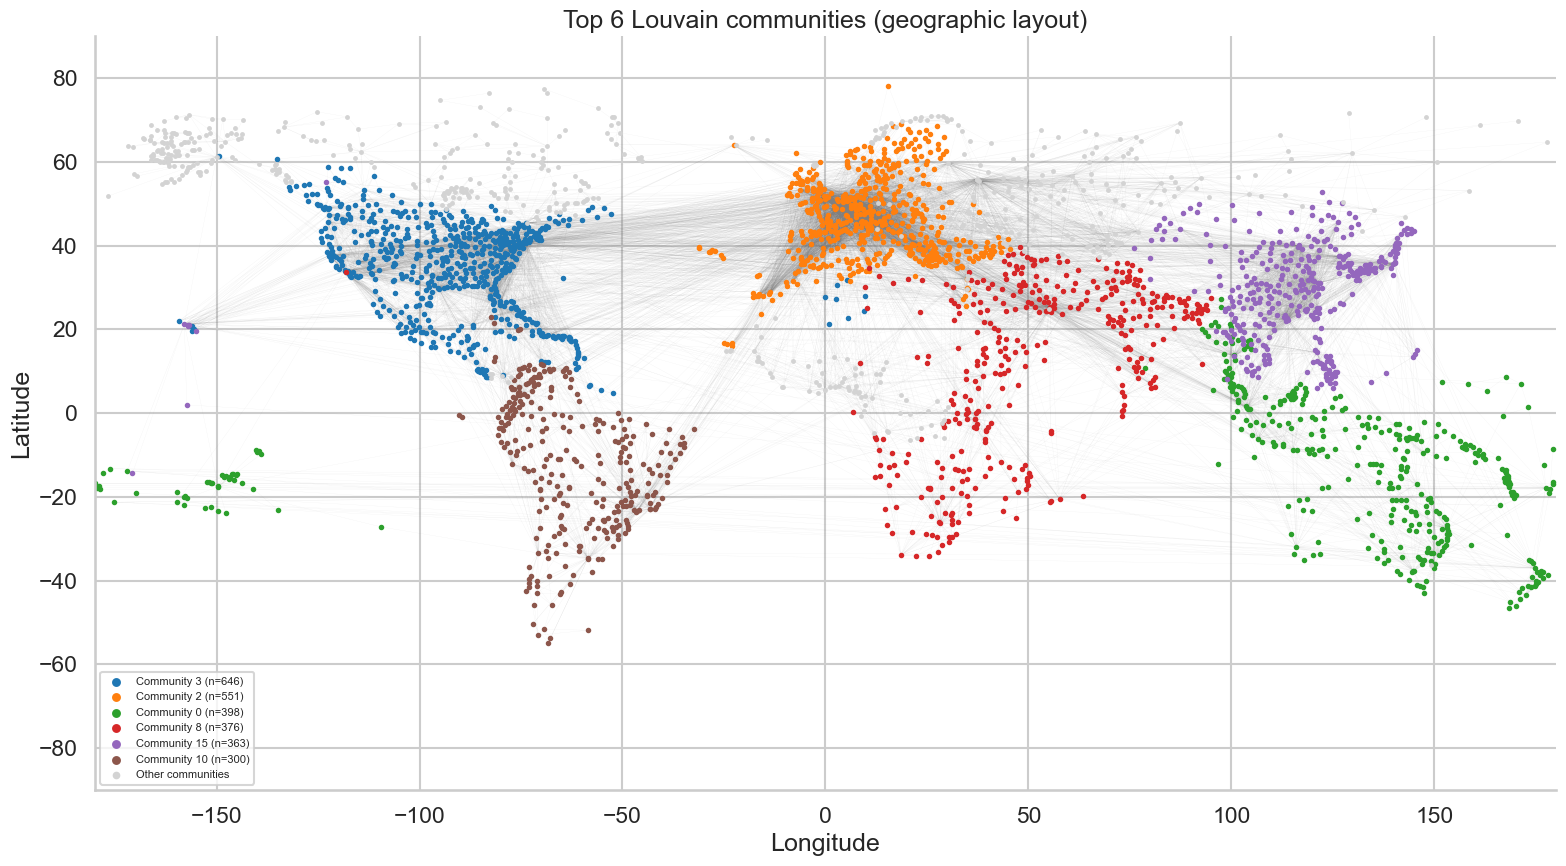

In [40]:
# Visualize the top 6 Louvain communities on a geographic layout

lon_g = np.array(giant_und.vs["longitude"])
lat_g = np.array(giant_und.vs["latitude"])

top_comm_ids = community_summary["community"].head(top_n_communities).tolist()
color_map = {cid: i for i, cid in enumerate(top_comm_ids)}
point_group = np.array([color_map.get(c, -1) for c in membership])

fig, ax = plt.subplots(figsize=(16, 9))
segments_g = [
    ((lon_g[e.source], lat_g[e.source]), (lon_g[e.target], lat_g[e.target]))
    for e in giant_und.es
]
ax.add_collection(LineCollection(segments_g, colors="gray", linewidths=0.15, alpha=0.15, zorder=1))

cmap = plt.get_cmap("tab10")
for cid in top_comm_ids:
    mask = point_group == color_map[cid]
    ax.scatter(lon_g[mask], lat_g[mask], s=6, color=cmap(color_map[cid]),
               label=f"Community {cid} (n={mask.sum()})", zorder=2)
other_mask = point_group == -1
ax.scatter(lon_g[other_mask], lat_g[other_mask], s=4, color="lightgray", label="Other communities", zorder=2)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Top {top_n_communities} Louvain communities (geographic layout)")
ax.legend(loc="lower left", markerscale=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

- It can be observed from the geographic plot that communities align closely with real world continents and regions, visually confirming the earlier tabular findings.


- Community 8 (red) shows a wide geographic spread with sparse, scattered points rather than a single dense cluster. It extends from the Middle East through South Asia into parts of Africa, consistent with Dubai International Airport's role as a connector hub linking distant regions rather than serving a tight local market.
- Community 2 (orange) is the most tightly packed cluster, with a dense web of connections reflecting high short haul flight density in Europe. Its network also stretches outward in all four directions,consistent with Europe's role as a major global aviation crossroads. 

***Note***: The result here shows the community profile from one Louvain run, using a fixed seed of 42 for reproducibility. Although the 50-run stability analysis in Section 8.1. shows high agreement between runs (NMI ≈ 0.92, ARI ≈ 0.89), some airports may still shift between communities, especially near community boundaries. Therefore, the exact community composition and highest-strength airport may vary slightly across runs. 

# Appendix: Glossary of Key Network Concepts


To support the interpretation of the methods and results presented in the analysis, core network science concepts will be briefly introduced. 
- ***Basic graph properties***: A network consists of nodes and edges; here, nodes represent airports and edges represent scheduled flights between them. It can be directed (edges have a defined origin and destination) or undirected, weighted (edges carry a value, e.g. number of flights) or unweighted, and a multigraph if multiple edges are allowed between the same node pair. Density is the proportion of all possible node pairs that are actually connected. Reciprocity, defined for directed networks, measures the share of edges for which the opposite-direction edge also exists.


- ***Degree, strength, and connectivity structure***: Degree is the number of edges incident to a node (split into in-/out-degree when directed); strength is its weighted equivalent. A connected component is a subset of nodes reachable from one another, with the giant component being the largest such subset. Diameter is the longest shortest path within a component; average shortest path length is the mean shortest-path distance across all reachable pairs, measured in hops or in a weighted unit (e.g., kilometres). The clustering coefficient measures how interconnected a node's neighbours are (averaged locally, or computed globally from closed vs. connected triplets). Coreness, from the k-core decomposition, reflects how deeply embedded a node is within the network's densest core.
- ***Node centrality measures***: Centrality measures capture different notions of "importance." Betweenness centrality counts shortest paths passing through a node (structural bridges). Harmonic closeness centrality sums the reciprocals of distances to reachable nodes, naturally handling unreachable ones. Eigenvector centrality and PageRank assign higher scores to nodes connected to other important nodes, with PageRank further accounting for directionality and weight. Eccentricity is a node's greatest shortest-path distance to any other node in its component.
- ***Distributions and concentration***: The degree distribution P(k) and its complementary cumulative form P(K ≥ k) (and the analogous strength CCDF) describe how connectivity is distributed across nodes, and are plotted on log-log axes to reveal heavy-tailed, hub-dominated behaviour. Spearman correlation, a non-parametric measure of monotonic association, is used to compare how consistently different centrality measures rank nodes. 
- ***Assortativity and mixing patterns***: Assortativity describes whether nodes preferentially connect to similar (assortative) or dissimilar (disassortative) nodes. The degree assortativity coefficient summarises this tendency with a single value; because it can conceal degree-dependent variation, the average nearest-neighbour degree function k_nn(k) is also used to examine mixing patterns separately at low, intermediate, and high degrees. Nominal and scalar assortativity extend this idea to categorical (country) and numerical (time zone) node attributes.
- ***Small-world properties and null models***: A network shows small-world behaviour when it combines high clustering with a short average path length, a combination unlikely in purely random networks. This can be tested by comparing the empirical network against random-graph null models: the Erdős–Rényi model (same number of nodes and edge density, random placement) and the configuration model (same degree sequence, otherwise randomised). The small-world coefficient sigma (σ) is computed as the ratio between the relative increase in clustering and the relative increase in path length observed in the empirical network compared to a null model; a value of σ substantially greater than 1 indicates genuine small-world structure.
- ***Community detection***: Community detection partitions a network into groups more densely connected internally than externally. Louvain and Label Propagation iteratively optimise local connectivity criteria; Walktrap uses random walks that tend to stay within communities; Infomap minimises the description length of a random walk. Modularity (Q) is a widely used metric that quantifies the quality of a given partition, measuring the extent to which the observed density of edges within communities exceeds what would be expected by chance; higher values indicate a stronger, more well-separated community structure. NMI and ARI measure agreement between repeated partitions (0 = no agreement, 1 = identical), used here to assess algorithm stability.
